**Lab2-DL: B2-learning-in-nn.ipynb** (BMED365) | Priority: 1 (core)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/B2-learning-in-nn.ipynb)

# 🎓 B2: Learning in Neural Networks

Using the `bmed365-2026` conda environment

Updated: 2025-12-22 ; 2026-01-15  A. Lundervold

**From Biology to Artificial Intelligence: How Neural Networks Learn**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Explain biological learning** | Describe Hebb's rule, LTP/LTD, and synaptic plasticity |
| **Understand gradient descent** | Explain how optimization finds minimum loss |
| **Derive backpropagation** | Trace how gradients flow backward through a network |
| **Apply the chain rule** | Calculate gradients for multi-layer networks |
| **Distinguish batch sizes** | Explain SGD vs mini-batch vs batch gradient descent |
| **Connect bio to AI learning** | Map biological mechanisms to artificial learning |

### What You Will Learn

In this notebook we will:
- **Understand** how learning occurs in biological neural networks
- **Compare** biological and artificial learning
- **Explore** backpropagation and gradient descent
- **Implement** training, validation, and testing
- **Examine** overfitting and generalization
- **Use** PyTorch for practical examples

---

## 🧠 1. Biological Foundation: How Does the Brain Learn?

Before we explore artificial neural networks, it is important to understand how learning occurs in biological neural networks - our brain.

### Neuroplasticity: The Brain's Learning Mechanism

**Neuroplasticity** is the brain's ability to change throughout life. This is the foundation for all learning and memory.

#### Types of Neuroplasticity

1. **Synaptic Plasticity**
   - Changes in the strength of synapses between neurons
   - **LTP (Long-Term Potentiation)**: Synapses become stronger with repeated stimulation
   - **LTD (Long-Term Depression)**: Synapses become weaker with lack of stimulation

2. **Structural Plasticity**
   - Formation of new synapses (synaptogenesis)
   - Growth of new dendrites and axons
   - Formation of new neurons (neurogenesis) in certain areas

3. **Functional Plasticity**
   - Changes in how neurons respond to stimuli
   - Reorganization of neural circuits

### Hebb's Rule: "Neurons that fire together, wire together"

**Donald Hebb (1949)** formulated the fundamental principle of neuroplasticity:

> "When an axon of cell A is near enough to excite cell B and repeatedly or persistently takes part in firing it, some growth process or metabolic change takes place in one or both cells such that A's efficiency, as one of the cells firing B, is increased."

**Practical significance**: Synapses become stronger when pre- and postsynaptic neurons are activated simultaneously.

### Molecular Mechanisms for Learning

#### 1. **NMDA Receptors and Calcium**
- NMDA receptors are activated by simultaneous glutamate binding and depolarization
- Calcium ions flow in and activate signaling pathways
- This leads to LTP and synaptic strengthening

#### 2. **Protein Synthesis**
- Calcium activates cAMP-response element binding protein (CREB)
- CREB regulates gene expression for proteins important for synaptic function
- New proteins change the synapse's structure and function

#### 3. **BDNF (Brain-Derived Neurotrophic Factor)**
- Growth factor that promotes neuronal survival and synaptogenesis
- Increased expression during learning and training
- Important for long-term memory and neuroplasticity

### Learning at the System Level

#### 1. **Short-term Memory**
- Activation of neural circuits in hippocampus and prefrontal cortex
- Requires continuous activity to be maintained
- Capacity: ~7±2 items (Miller's Magic Number)<br>
   - Miller, G. A. (1956). The magical number seven, plus or minus two: Some limits on our capacity for processing information. [[link](https://psychclassics.yorku.ca/Miller)]

#### 2. **Long-term Memory**
- Consolidation through protein synthesis
- Reorganization from hippocampus to neocortex
- Can last a lifetime

#### 3. **Procedural Learning**
- Basal ganglia and cerebellum
- Automation of motor and cognitive skills
- "Muscle memory" - automatic responses

### Clinical Relevance

#### **Rehabilitation after Brain Injury**
- Neuroplasticity enables compensation and recovery of function
- Early intervention is critical
- Repetitive training promotes reorganization

#### **Aging and Cognitive Decline**
- Neuroplasticity decreases with age
- But can be promoted through:
  - Physical activity
  - Mental stimulation
  - Social interaction
  - New learning

#### **Mental Disorders**
- Depression: Reduced neurogenesis and synaptic plasticity
- PTSD: Disturbed consolidation of traumatic memories
- Schizophrenia: Changes in synaptic function and neuroplasticity

#### Comparison: Biological vs Artificial Learning

| Aspect | Biological (Brain) | Artificial (Neural Networks) |
|--------|-------------------|---------------------------|
| **Learning Mechanism** | Synaptic plasticity | Gradient descent |
| **Time Scale** | Milliseconds to years | Seconds to hours |
| **Energy Consumption** | ~20W (whole brain) | Varies greatly - from 100 W (small research models) to megawatts (largest models) during training |
| **Robustness** | High fault tolerance | Can be sensitive |
| **Adaptability** | Continuous learning | Often batch learning |
| **Explainability** | Complex, partially understood | Mathematically precise |
| **Creativity** | High creativity | Limited |
| **Generalization Ability** | Excellent | Varies |



### **Reinforcement Learning**: Reward and Punishment in the Brain

**Reinforcement learning** (**RL**) is a fundamental learning mechanism found in both biological and artificial systems. In the brain, this occurs through dopaminergic systems that reward desired behavior.

#### Biological Mechanisms for Reinforcement Learning

**1. Dopaminergic Systems**
- **Ventral Tegmental Area (VTA)** and **Substantia Nigra** produce dopamine
- **Nucleus Accumbens** receives dopamine and codes for reward
- **Prefrontal Cortex** integrates reward information for decision-making

**2. Reward Prediction and Error**
- **Dopamine levels** reflect the difference between expected reward and actual reward
- **Positive errors**: Higher reward than expected → Increased dopamine
- **Negative errors**: Lower reward than expected → Reduced dopamine

**3. Temporal Difference Learning**
- The brain learns to predict future rewards
- **Immediate reward**: Immediate reward
- **Delayed reward**: Reward that comes later
- **Discounting**: Future rewards are weighted lower


Here is a more precise formulation of reward prediction and error:

**Reward Prediction and Error**

**Dopamine levels** reflect the difference between expected and actual reward:

$\Delta R(t) = R(t) - \hat{R}(t)$

Where:
- $\Delta R(t)$ = reward prediction error
- $R(t)$ = actual reward at time $t$
- $\hat{R}(t)$ = expected reward at time $t$

**Dopamine response** is proportional to the reward prediction error:

$DA(t) \propto \Delta R(t)$

**Positive errors** (higher reward than expected):

$\Delta R(t) > 0 \Rightarrow DA(t) > 0 \text{ (increased dopamine)}$

**Negative errors** (lower reward than expected):

$\Delta R(t) < 0 \Rightarrow DA(t) < 0 \text{ (reduced dopamine)}$

**Temporal Difference Learning**:

$\Delta R(t) = R(t) + \gamma \hat{V}(s_{t+1}) - \hat{V}(s_t)$

Where:
- $\gamma$ = discount factor (0 < γ ≤ 1)
- $\hat{V}(s_t)$ = expected value of state $s_t$*****

This is the core of **Temporal Difference (TD) learning** which is the foundation for both biological and artificial reinforcement learning.


#### Clinical Relevance for Helse

**1. Addiction and Reward Systems**
- **Substance abuse** hijacks natural reward systems
- **Tolerance**: Increased need for stimulus for the same reward feeling
- **Addiction**: Compulsive behavior despite negative consequences

**2. Learning and Rehabilitation**
- **Positive reinforcement** promotes desired behavior
- **Negative reinforcement** reduces undesired behavior
- **Shaping**: Gradual approach to target skills

**3. Clinical Application**
- **Cognitive Behavioral Therapy (CBT)**: Uses principles of reinforcement learning
- **Motivational interviewing**: Reinforces change-oriented behavior
- **Gamification**: Uses reward systems in treatment

#### Comparison: Brain vs. Artificial Reinforcement Learning

| Aspekt | Biologisk (Hjernen) | Kunstig (RL) |
|--------|-------------------|--------------|
| **Reward Signal** | Dopamine | Numerical reward |
| **Time Scale** | Milliseconds | Discrete/episodic |
| **Exploration** | Curiosity, novelty-seeking | Epsilon-greedy******, UCB****** |
| **Memory** | Hippocampus + Neocortex | Experience replay |
| **Generalization** | High | Depends on representation |
| **Kreativitet** | Høy | Begrenset |

**Important for Healthcare Professionals:**
- Understand that **motivation** and **reward** are fundamental learning mechanisms
- **AI systems** can use similar principles to learn optimal behavior
- **Clinical relevance** for treatment of addiction and behavioral change


**(*)** What does state $s_t$ mean?

"State $s_t$" represents different things in the brain versus AI, but both have the same fundamental function.

### In the Brain (Biological)

**State $s_t$** represents the **neural activity state** in relevant brain regions:

#### Examples of states:
- **Sensory state**: "I see food" (visual cortex activity)
- **Motivational state**: "I am hungry" (hypothalamus activity)
- **Spatial state**: "I am in the kitchen" (hippocampus place cells)
- **Emotional state**: "I feel happy" (limbic system activity)
- **Motor state**: "I am reaching out my hand" (motor cortex activity)

#### Concrete example:
When you learn to find food in the kitchen:
- $s_t$ = "I am standing in the kitchen and see the refrigerator"
- $s_{t+1}$ = "I have opened the refrigerator and see food"
- $\hat{V}(s_t)$ = "How much reward do I expect from this situation?"

### In AI (Artificial)

**State $s_t$** represents the **digital representation** of the environment:

#### Examples of states:
- **Game**: "The player is at position (x,y) with 3 lives remaining"
- **Robot**: "The robot is 2 meters from the target, facing north, has 50% battery"
- **Medical AI**: "Patient has temperature 38.5°C, pulse 90, blood pressure 140/90"
- **Financial AI**: "Stock price is 850 kr, volume is 500,000, RSI (Relative Strength Index) is 65" <br>
       (e.g., "Equinor stock has risen 2% today, trading volume is above average")

#### Concrete example:
An AI learning to play Pac-Man:
- $s_t$ = "Pac-Man is at position (10,5), ghost at position (8,3), 3 dots remaining"
- $s_{t+1}$ = "Pac-Man ate a dot, now 2 dots remaining"
- $\hat{V}(s_t)$ = "How many points does the AI expect from this position?"

### Comparison

| Aspect | Brain | AI |
|--------|---------|-----|
| **Representation** | Neural activity | Numerical values |
| **Complexity** | ~86 billion neurons | Limited by computational power |
| **Continuous** | Analog, fluid | Often discrete |
| **Context** | Rich, multimodal | Dependent on sensors |
| **Memory** | Hippocampus + Neocortex | Experience replay buffer**#** |

### Clinical Relevance

**For healthcare professionals** this is important because:

1. **Patient states**: AI can learn to predict outcomes based on patient data
2. **Treatment choices**: Systems can learn optimal treatment for different states
3. **Diagnostics**: AI can recognize patterns in patient states

**Example**: An AI learning to dose insulin:
- $s_t$ = "Blood sugar: 180 mg/dL, time: 14:00, last meal: 2 hours ago"
- $\hat{V}(s_t)$ = "Expected reward (stable blood sugar) from this state"
- AI learns to predict which doses give the best result for different states

The state is thus a "snapshot" of the situation that the system uses to make decisions and learn from results.

**(#)** What is an "Experience Replay Buffer"?


**Experience Replay Buffer** is an important technique in reinforcement learning that helps AI systems learn more effectively by storing and reusing past experiences.

#### What is it?

Experience Replay Buffer is a **data structure** that stores:
- **State** ($s_t$): What happened
- **Action** ($a_t$): What the AI did
- **Reward** ($r_t$): How well it went
- **Next state** ($s_{t+1}$): What happened afterwards

#### How does it work?

##### 1. **Storage**:
```
Buffer = [(s₁, a₁, r₁, s₂), (s₂, a₂, r₂, s₃), (s₃, a₃, r₃, s₄), ...]
```

##### 2. **Training**:
- Instead of learning only from the last experience
- The AI selects **random** experiences from the buffer
- This breaks the correlation between consecutive experiences

##### 3. **Benefits**:
- **Stabilization**: Reduces variance in learning
- **Efficiency**: Reuses previous data
- **Diversity**: Learns from many different situations

#### Practical example:

**An AI learning to play a game**:
- **Buffer**: Stores 10,000 previous game rounds
- **Training**: Randomly selects 32 experiences from the buffer
- **Learning**: Uses these to update the strategy

#### Comparison med Biologisk Minne

| Aspect | Experience Replay | Brain |
|--------|------------------|---------|
| **Storage** | Digital buffer | Hippocampus + Neocortex |
| **Access** | Random sampling | Associative recall |
| **Capacity** | Limited size | Practically unlimited |
| **Consolidation** | None | Long-term memory |
| **Emotions** | None | Strong influence |

#### Clinical Relevance

**For healthcare professionals** this is relevant because:

##### 1. **Medical AI Systems**:
- **Diagnostics**: Learns from thousands of patient cases
- **Treatment**: Uses experience from similar patients
- **Prediction**: Predicts outcomes based on historical data

##### 2. **Clinical Decision Making**:
- **Pattern recognition**: Recognizes patterns in patient data
- **Risk assessment**: Assesses risk based on previous cases
- **Treatment optimization**: Finds best treatment based on experience

##### 3. **Example in Practice**:
An AI learning to diagnose heart attacks:
- **Buffer**: Stores 50,000 patient cases with ECG, symptoms, and diagnosis
- **Training**: Randomly selects 100 cases for each training round
- **Learning**: Improves diagnostic accuracy over time

**Key point**: Experience Replay, inspired by human learning, helps the AI learn by "reflecting" on past experiences and drawing lessons from them, instead of just reacting to what is happening right now.


**(**)** What do **Epsilon-greedy** and **UCB** mean in the context of reinforcement learning? 

These are algorithms used to balance between **exploration** and **exploitation** in AI systems.

#### Epsilon-greedy (ε-greedy)

**Epsilon-greedy** is a simple but effective strategy for handling the **exploration vs exploitation** dilemma:

##### How it works:
- **Exploitation (1-ε)**: Choose the action that currently looks best (highest expected reward)
- **Exploration (ε)**: Choose a random action to explore new possibilities

##### Example:
- If ε = 0.1 (10%), the system will:
  - 90% of the time choose the best known action
  - 10% of the time choose a random action

##### Practical example:
An AI learning to play a game:
- **Exploitation**: Use the strategy that has given the best result so far
- **Exploration**: Try a new strategy to see if it might be even better

#### UCB (Upper Confidence Bound)

**UCB** is a more sophisticated strategy that uses statistical theory to balance exploration and exploitation:

##### How it works:
UCB chooses the action with the highest **"upper confidence bound"** - a combination of:
1. **Expected reward** (exploitation)
2. **Uncertainty** (exploration)

##### The formula:
```
UCB(a) = Q(a) + c × √(ln(t) / N(a))
```

Where:
- `Q(a)` = average reward for action a
- `c` = confidence level (how much exploration)
- `t` = total number of attempts
- `N(a)` = number of times action a has been tried

##### Practical example:
An AI learning to choose between different treatment methods:
- **High Q(a)**: Treatment that has given good results
- **High uncertainty**: Treatment that has not been tried as often
- **UCB chooses**: Treatment with best combination of good result and high uncertainty

#### Comparison med Biologisk Læring

| Aspect | Biological (Brain) | Epsilon-greedy | UCB |
|--------|-------------------|----------------|-----|
| **Exploration** | Curiosity, spontaneous activity | Random choice | Statistical uncertainty |
| **Exploitation** | Repetition of successful actions | Best known action | Highest expected reward |
| **Adaptability** | Dynamic based on context | Fixed ε-value | Dynamic based on uncertainty |
| **Complexity** | High (many factors) | Low | Medium |

#### Clinical Relevance

**For healthcare professionals** this is relevant because:

1. **Treatment choices**: AI systems can use these strategies to learn optimal treatment
2. **Clinical trials**: The principles are similar to adaptive clinical trials
3. **Personalized medicine**: Systems can learn individually optimal treatments

**Example in practice**:
- An AI learning to dose medication can use UCB to balance between using doses that have worked well and trying new doses to find even better alternatives.

These algorithms help AI systems learn in a way that resembles how humans balance between using what we know works and exploring new possibilities.

---

##  🤖 2. From Biology to Artificial Intelligence

Now that we have gained insight into biological learning, we can see how artificial neural networks inspired by the brain work.

### Theoretical Foundation

### How Does an Artificial Neural Network Learn?

Learning in artificial neural networks occurs through **optimization** - we adjust the weights to minimize error:

1. **Forward pass**: Compute prediction from input
2. **Calculate error**: Compare prediction with "ground truth" 
3. **Backward pass**: Calculate gradients (how to change weights)
4. **Update weights**: Adjust weights in direction that reduces error
5. **Repeat**: Continue until convergence

### Mathematical Formulation

**Loss function**: L(θ) = Σ loss(f(xᵢ, θ), yᵢ)

**Gradient Descent**: θ ← θ - α∇L(θ)

### Symbol Definitions

**The loss function** measures how well our model is doing:

- **L(θ)** = Total loss for the model with parameters θ
- **Σ** = Sum over all examples in the training set
- **loss()** = Loss function that measures error for one example
- **f(xᵢ, θ)** = Model's prediction for input xᵢ with parameters θ
- **xᵢ** = Input example number i (e.g., patient data)
- **yᵢ** = True value for example i (e.g., diagnosis)
- **θ** = All model parameters (weights and biases)

**Gradient Descent** updates the parameters:

- **α** = Learning rate (how large steps we take)
- **∇L(θ)** = Gradient of the loss function (direction for change)
- **←** = Update (new value becomes left side)

### Examples of Loss Functions

The loss function **loss()** measures how wrong the model's prediction is. Here are common examples:

#### 1. **Mean Squared Error (MSE)** - For Regression
```
loss(y_true, y_pred) = (y_true - y_pred)²
```
**Medical example**: Prediction of blood pressure
- If true value is 120 mmHg and the model predicts 125 mmHg
- Loss = (120 - 125)² = 25

#### 2. **Cross-Entropy Loss** - For Classification
```
loss(y_true, y_pred) = -y_true × log(y_pred)
```
**Medical example**: Diagnosis of disease (0=healthy, 1=sick)
- If patient is sick (y_true=1) and the model predicts 90% probability of disease
- Loss = -1 × log(0.9) = 0.105 (low loss = good prediction)
- If the model predicts 10% probability of disease
- Loss = -1 × log(0.1) = 2.303 (high loss = poor prediction)

#### 3. **Binary Cross-Entropy** - For Binary Classification
```
loss(y_true, y_pred) = -[y_true×log(y_pred) + (1-y_true)×log(1-y_pred)]
```
**Medical example**: Prediction of heart attack
- Healthy patient (y_true=0) with 20% risk: loss = -[0×log(0.2) + 1×log(0.8)] = 0.223
- Sick patient (y_true=1) with 80% risk: loss = -[1×log(0.8) + 0×log(0.2)] = 0.223

#### 4. **Hinge Loss** - For Support Vector Machines
```
loss(y_true, y_pred) = max(0, 1 - y_true × y_pred)
```
**Medical example**: Classification of cancer stages
- If true class is +1 and the model predicts +0.8
- Loss = max(0, 1 - 1×0.8) = max(0, 0.2) = 0.2

#### 5. **Huber Loss** - Robust Against Outliers
```
loss(y_true, y_pred) = {
    0.5 × (y_true - y_pred)²     if |y_true - y_pred| ≤ δ
    δ × |y_true - y_pred| - 0.5 × δ²  otherwise
}
```
**Medical example**: Prediction of blood pressure med uteliggere
- **δ (delta)** = Threshold value that determines when to switch from quadratic to linear loss
- **Small errors** (≤ δ): Uses quadratic loss like MSE
- **Large errors** (> δ): Uses linear loss like MAE

**Practical example** with δ = 10:
- Error of 5 mmHg: loss = 0.5 × 5² = 12.5 (quadratic)
- Error of 15 mmHg: loss = 10 × 15 - 0.5 × 10² = 100 (linear)

**Benefits**:
- **Robust against outliers**: Large errors are not penalized as harshly as with MSE
- **Smooth transition**: Continuous function without kinks
- **Balances MSE and MAE**: Combines best properties from both

### Why Different Loss Functions?

- **MSE**: Best for continuous values (blood pressure, temperature)
- **Cross-Entropy**: Best for probabilities and classification
- **Hinge Loss**: Best for margin-based classifiers
- **Huber Loss**: Robust against outliers (combines MSE and MAE)

### Practical Significance

Choice of loss function affects:
- **How quickly** the model learns
- **Which errors** are most penalized
- **Robustness** against outliers in the data
- **The balance** between false positives and false negatives


In [1]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Core Scientific Computing ===
import numpy as np                    # Numerical arrays and operations
import matplotlib.pyplot as plt       # Plotting and visualization
import seaborn as sns                 # Statistical visualization

# === Deep Learning Framework ===
import torch                          # PyTorch: tensors, autograd
import torch.nn as nn                 # Neural network layers
import torch.optim as optim           # Optimizers (SGD, Adam, etc.)
from torch.utils.data import DataLoader, TensorDataset  # Data utilities

# === Machine Learning Utilities ===
from sklearn.datasets import make_classification    # Synthetic datasets
from sklearn.model_selection import train_test_split  # Train/test splitting
from sklearn.preprocessing import StandardScaler    # Feature normalization

# === Utility ===
import warnings
warnings.filterwarnings('ignore')     # Suppress warnings for cleaner output

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# Setting random seeds ensures consistent results across runs
# This is critical for scientific reproducibility and debugging

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)           # NumPy random operations
torch.manual_seed(RANDOM_SEED)        # PyTorch CPU operations
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)  # PyTorch GPU operations

# =============================================================================
# VISUALIZATION SETTINGS
# =============================================================================
plt.style.use('seaborn-v0_8')         # Modern, clean plot style
sns.set_palette("husl")               # Colorblind-friendly palette

print("🎓 Ready for learning in neural networks!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")


🎓 Ready for learning in neural networks!
PyTorch version: 2.6.0
CUDA available: False
MPS available: True
🎲 Random seed set to 42 for reproducibility


----

## 3. Gradient Descent: The Path to Optimization and the "Engine" of AI Learning

### Intuition: Finding the Lowest Point

Imagine you are blindfolded on a mountaintop and need to find the valley. You can:
1. **Feel the terrain** around you (calculate gradient)
2. **Walk in the direction** that goes downhill (update weights)
3. **Repeat** until you reach the bottom (convergence)

This is exactly what gradient descent does!

### Mathematical Understanding

**Gradient** = the direction with greatest slope
**Gradient Descent** = go in the opposite direction (downhill)

**θ ← θ - α∇L(θ)**

Where:
- **α** (alpha) = learning rate (step size)
- **∇L(θ)** = gradient (direction)
- **-** = go in the opposite direction


_Visualization of gradient descent along one dimension_

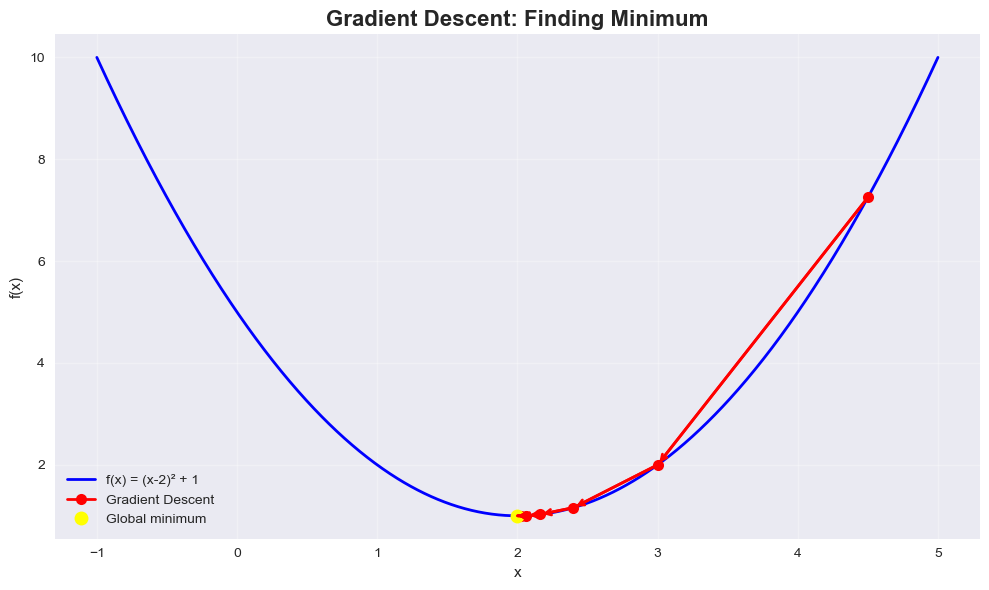

Starting point: x = 4.50, f(x) = 7.25
Endpoint: x = 2.00, f(x) = 1.00
Optimal: x = 2.00, f(x) = 1.00


In [2]:
# =============================================================================
# GRADIENT DESCENT VISUALIZATION
# =============================================================================
# Gradient descent is THE fundamental optimization algorithm for neural networks.
# It finds the minimum of a function by repeatedly taking steps in the 
# direction of steepest descent (negative gradient).
#
# BIOLOGICAL ANALOGY:
#   Like a ball rolling downhill - it naturally moves toward the lowest point.
#   In neural networks, the "hill" is the loss function, and we want to find
#   the weights that minimize the loss.
#
# KEY FORMULA:
#   θ_new = θ_old - α × ∇L(θ)
#   Where:
#     θ = parameters (weights)
#     α = learning rate (step size)
#     ∇L = gradient of loss (direction of steepest ascent)
# =============================================================================

def visualize_gradient_descent():
    """
    Visualize gradient descent on a simple quadratic function.
    
    This demonstrates the core concept: iteratively moving toward the minimum
    by following the negative gradient.
    """
    # Define a simple function: f(x) = (x-2)² + 1
    # This is a parabola with minimum at x=2, f(2)=1
    x = np.linspace(-1, 5, 1000)
    y = (x - 2)**2 + 1
    
    # === Gradient descent simulation ===
    learning_rate = 0.3   # α: step size (too large → overshoot, too small → slow)
    x_current = 4.5       # Starting point (far from minimum at x=2)
    iterations = 10       # Number of update steps
    
    # Track history for visualization
    x_history = [x_current]
    y_history = [(x_current - 2)**2 + 1]
    
    for i in range(iterations):
        # Calculate gradient: f'(x) = 2(x-2)
        # Gradient tells us: positive → go left, negative → go right
        gradient = 2 * (x_current - 2)
        
        # Update x: x = x - α * gradient
        # Subtract gradient because we want to DESCEND (minimize)
        x_current = x_current - learning_rate * gradient
        
        x_history.append(x_current)
        y_history.append((x_current - 2)**2 + 1)
    
    # Plot the result
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(x, y, 'b-', linewidth=2, label='f(x) = (x-2)² + 1')
    ax.plot(x_history, y_history, 'ro-', linewidth=2, markersize=8, label='Gradient Descent')
    
    # Add arrows to show direction
    for i in range(len(x_history)-1):
        ax.annotate('', xy=(x_history[i+1], y_history[i+1]), 
                   xytext=(x_history[i], y_history[i]),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2))
    
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title('Gradient Descent: Finding Minimum', fontsize=16, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Mark minimum
    ax.plot(2, 1, 'go', markersize=10, label='Global minimum', color='yellow')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Starting point: x = {x_history[0]:.2f}, f(x) = {y_history[0]:.2f}")
    print(f"Endpoint: x = {x_history[-1]:.2f}, f(x) = {y_history[-1]:.2f}")
    print(f"Optimal: x = 2.00, f(x) = 1.00")

visualize_gradient_descent()


_3D visualization of gradient descent in two dimensions_

### Gradient Descent in 2D: From Mountain to Valley

In reality, neural networks have thousands of parameters, not just one. Let's see how gradient descent works in two dimensions:

#### What Happens in 2D?

**Note**: 2D refers to the parameter space: the input dimensions (x,y), not the visualization which is a 3D plot of a 2D function (height z=f(x,y) as the third dimension)


- **Gradient** becomes a vector: ∇f = (∂f/∂x, ∂f/∂y)
- **Direction** shows where the terrain rises most
- **Magnitude** shows how steep it is
- **Update**: (x,y) ← (x,y) - α × ∇f

#### Geographic Analogy

Imagine you are on a mountaintop and need to find the valley:
- **Gradient** = the direction with greatest slope
- **Gradient Descent** = go in the opposite direction
- **Learning rate** = how large steps you take
- **Minimum** = the valley (optimal solution)

#### Visualization

Below you see two visualizations:
1. **Contour plot**: Like a topographic map with elevation lines
2. **3D Surface**: Like an actual mountain with a valley


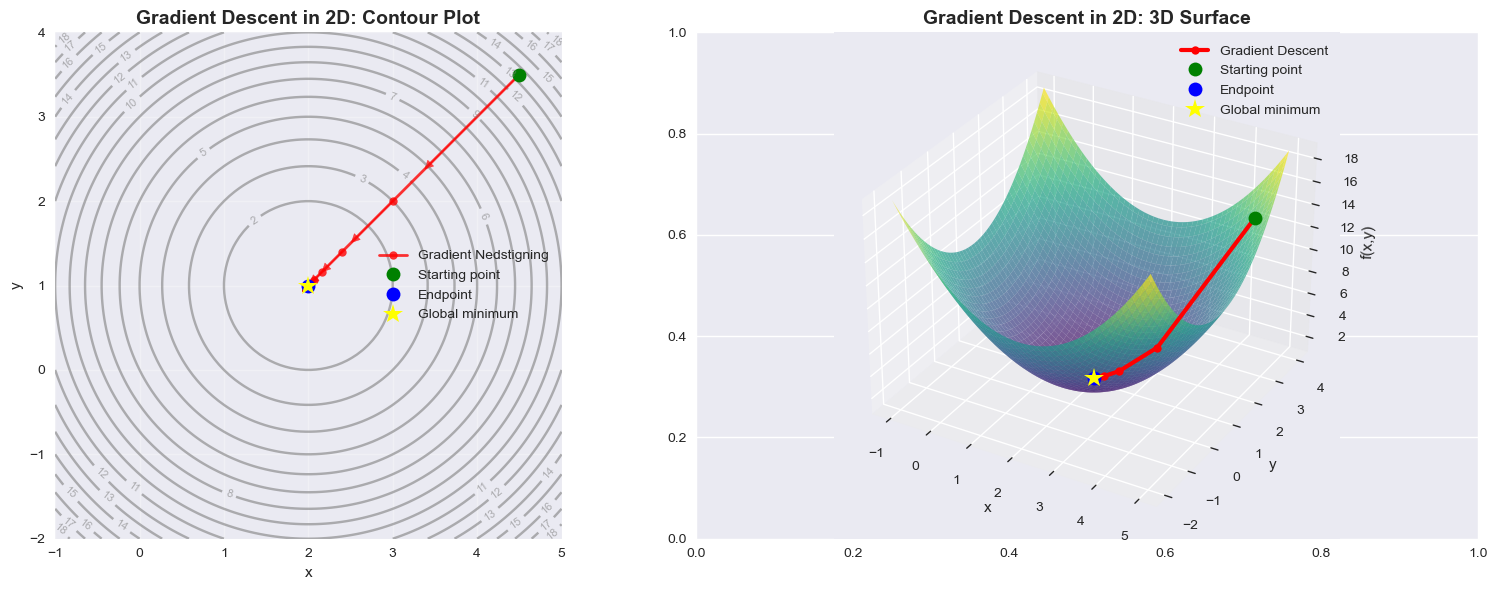

=== Gradient Descent in 2D ===
Starting point: (4.50, 3.50), f(x,y) = 13.50
Endpoint: (2.00, 1.00), f(x,y) = 1.00
Optimal: (2.00, 1.00), f(x,y) = 1.00
Number of iterations: 15
Learning rate: 0.3


In [3]:
# Visualiser gradient descent i 2D
def visualize_gradient_descent_2d():
    """Visualize gradient descent on a 2D function"""
    
    # Define a 2D function: f(x,y) = (x-2)² + (y-1)² + 1
    # This has minimum at (2, 1)
    
    # Create a grid for plotting
    x = np.linspace(-1, 5, 100)
    y = np.linspace(-2, 4, 100)
    X, Y = np.meshgrid(x, y)
    Z = (X - 2)**2 + (Y - 1)**2 + 1
    
    # Gradient descent simulation
    learning_rate = 0.3
    x_current, y_current = 4.5, 3.5  # Starting point
    iterations = 15
    
    # Store history
    x_history = [x_current]
    y_history = [y_current]
    z_history = [(x_current - 2)**2 + (y_current - 1)**2 + 1]
    
    for i in range(iterations):
        # Calculate gradient: ∇f = (2(x-2), 2(y-1))
        grad_x = 2 * (x_current - 2)
        grad_y = 2 * (y_current - 1)
        
        # Update position: (x,y) = (x,y) - α * ∇f
        x_current = x_current - learning_rate * grad_x
        y_current = y_current - learning_rate * grad_y
        
        x_history.append(x_current)
        y_history.append(y_current)
        z_history.append((x_current - 2)**2 + (y_current - 1)**2 + 1)
    
    # Plot the result
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Contour plot with gradient descent
    contour = ax1.contour(X, Y, Z, levels=20, colors='gray', alpha=0.6)
    ax1.clabel(contour, inline=True, fontsize=8)
    
    # Plot gradient descent path
    ax1.plot(x_history, y_history, 'ro-', linewidth=2, markersize=6, 
             label='Gradient Nedstigning', alpha=0.8)
    
    # Add arrows to show direction
    for i in range(len(x_history)-1):
        dx = x_history[i+1] - x_history[i]
        dy = y_history[i+1] - y_history[i]
        ax1.arrow(x_history[i], y_history[i], dx*0.7, dy*0.7, 
                 head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
    
    # Mark start and end
    ax1.plot(x_history[0], y_history[0], 'go', markersize=10, label='Starting point')
    ax1.plot(x_history[-1], y_history[-1], 'bo', markersize=10, label='Endpoint')
    ax1.plot(2, 1, 'r*', markersize=15, label='Global minimum', color='yellow')
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Gradient Descent in 2D: Contour Plot', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: 3D surface plot
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, linewidth=0)
    
    # Plot gradient descent path on the surface
    z_path = [(x_history[i] - 2)**2 + (y_history[i] - 1)**2 + 1 for i in range(len(x_history))]
    ax2.plot(x_history, y_history, z_path, 'ro-', linewidth=3, markersize=6, 
             label='Gradient Descent')
    
    # Mark start and end
    ax2.plot([x_history[0]], [y_history[0]], [z_path[0]], 'go', markersize=10, label='Starting point')
    ax2.plot([x_history[-1]], [y_history[-1]], [z_path[-1]], 'bo', markersize=10, label='Endpoint')
    ax2.plot([2], [1], [1], 'r*', markersize=15, label='Global minimum', color='yellow')
    
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('f(x,y)')
    ax2.set_title('Gradient Descent in 2D: 3D Surface', fontsize=14, fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    print(f"=== Gradient Descent in 2D ===")
    print(f"Starting point: ({x_history[0]:.2f}, {y_history[0]:.2f}), f(x,y) = {z_path[0]:.2f}")
    print(f"Endpoint: ({x_history[-1]:.2f}, {y_history[-1]:.2f}), f(x,y) = {z_path[-1]:.2f}")
    print(f"Optimal: (2.00, 1.00), f(x,y) = 1.00")
    print(f"Number of iterations: {iterations}")
    print(f"Learning rate: {learning_rate}")

visualize_gradient_descent_2d()


### ✅ Check Your Understanding: Gradient Descent

**Q1:** What happens if the learning rate is too large?

<details>
<summary>Click for answer</summary>

**Answer:** If the learning rate (α) is too large:
- The algorithm **overshoots** the minimum
- It may **oscillate** back and forth without converging
- In extreme cases, it can **diverge** to infinity

Analogy: Taking huge steps down a mountain - you might jump over the valley!

**Solution:** Start with a smaller learning rate, or use adaptive methods (Adam, RMSprop).
</details>

**Q2:** What happens if the learning rate is too small?

<details>
<summary>Click for answer</summary>

**Answer:** If the learning rate is too small:
- Convergence is **very slow** (many iterations needed)
- Training takes **much longer**
- May get **stuck in local minima** (not enough momentum to escape)

Analogy: Taking tiny baby steps down a mountain - you'll get there, but it takes forever!

**Solution:** Use learning rate schedulers that start large and decrease over time.
</details>

**Q3:** Why do we subtract the gradient instead of adding it?

<details>
<summary>Click for answer</summary>

**Answer:** 
- The **gradient** points in the direction of **steepest ASCENT** (uphill)
- We want to **DESCEND** (minimize the loss), so we go **opposite** to the gradient
- Formula: θ_new = θ_old - α × ∇L(θ)

The negative sign turns "climbing" into "descending"!
</details>

> 💡 **Medical AI Connection:** Learning rate tuning is crucial in medical imaging models. Too aggressive → unstable training; too conservative → impractical training times on large datasets like chest X-rays.

---

_Visualization of a more complex surface with illustration of gradient descent_

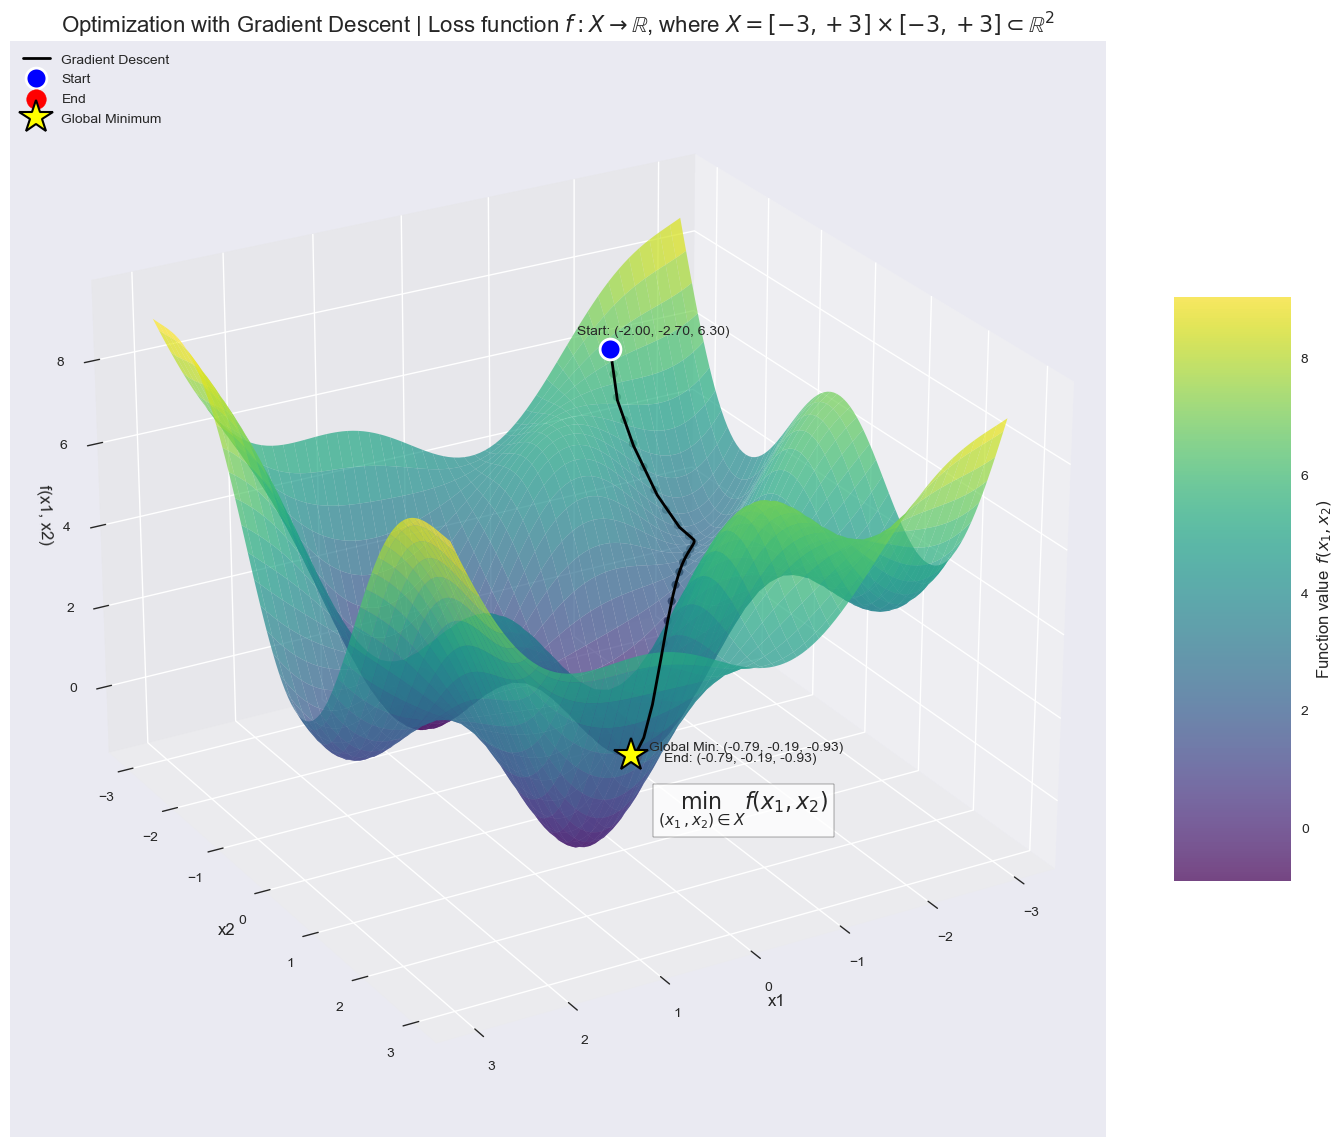


=== Objective function (loss function) ===
f(x₁, x₂) = 0.5(x₁² + x₂²) + 2sin(1.5x₁)cos(1.5x₂) + sin(2x₁)cos(2x₂) + 3e^(-((x₁+1)² + (x₂-1)²)/2)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from scipy.interpolate import interp1d

def objective_function(x):
    x1, x2 = x
    return (0.5 * (x1**2 + x2**2) + 
            2 * np.sin(1.5*x1) * np.cos(1.5*x2) + 
            np.sin(2*x1) * np.cos(2*x2) +
            3 * np.exp(-((x1+1)**2 + (x2-1)**2)/2))

def gradient(x):
    x1, x2 = x
    dx1 = (x1 + 
           3 * np.cos(1.5*x1) * np.cos(1.5*x2) + 
           2 * np.cos(2*x1) * np.cos(2*x2) - 
           3*(x1+1)*np.exp(-((x1+1)**2 + (x2-1)**2)/2))
    dx2 = (x2 - 
           3 * np.sin(1.5*x1) * np.sin(1.5*x2) - 
           2 * np.sin(2*x1) * np.sin(2*x2) - 
           3*(x2-1)*np.exp(-((x1+1)**2 + (x2-1)**2)/2))
    return np.array([dx1, dx2])

# Find the global minimum numerically
result = minimize(objective_function, [0, 0], method='BFGS')
global_min = result.x

# Generate data for the surface plot
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = objective_function([X1, X2])

# Create figure and 3D axis
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)

# Gradient descent
learning_rate = 0.08  # Adjusted learning rate
num_iterations = 60   # Increased number of iterations
start_point = np.array([-2.0, -2.7])
path = [start_point]

for _ in range(num_iterations):
    grad = gradient(path[-1])
    new_point = path[-1] - learning_rate * grad
    path.append(new_point)

path = np.array(path)

# Interpolate the path to get 25 equidistant points
cumulative_distances = np.cumsum(np.sqrt(np.sum(np.diff(path, axis=0)**2, axis=1)))
cumulative_distances = np.insert(cumulative_distances, 0, 0)
interpolator = interp1d(cumulative_distances, path, axis=0, kind='linear')
equidistant_distances = np.linspace(0, cumulative_distances[-1], 25)
equidistant_points = interpolator(equidistant_distances)

# Plot gradient descent path
gd_line = ax.plot(path[:, 0], path[:, 1], objective_function(path.T), 'k-', linewidth=2, label='Gradient Descent')[0]
gd_line.set_zorder(10)

# Plot equidistant points
equidistant_z = objective_function(equidistant_points.T)
ax.scatter(equidistant_points[:, 0], equidistant_points[:, 1], equidistant_z, color='black', s=30, zorder=12)

# Mark start and end points
start_z = objective_function(path[0])
end_z = objective_function(path[-1])
ax.plot([path[0, 0]], [path[0, 1]], [start_z], 'o', color='blue', markersize=15, markeredgecolor='white', markeredgewidth=2, label='Start', zorder=100)
end_point = ax.scatter(path[-1, 0], path[-1, 1], end_z, color='red', s=200, label='End', zorder=11)

# Mark global minimum
global_min_z = objective_function(global_min)
ax.plot([global_min[0]], [global_min[1]], [global_min_z], '*', color='yellow', markersize=25, markeredgecolor='black', markeredgewidth=1.5, label='Global Minimum', zorder=100)

# Add coordinates as text
ax.text(path[0, 0]+0.1, path[0, 1]-0.5, start_z, f'Start: ({path[0, 0]:.2f}, {path[0, 1]:.2f}, {start_z:.2f})', fontsize=10, zorder=11)
ax.text(path[-1, 0]-0.2, path[-1, 1]+0.3, end_z, f'End: ({path[-1, 0]:.2f}, {path[-1, 1]:.2f}, {end_z:.2f})', fontsize=10, zorder=11)
ax.text(global_min[0]-0.2, global_min[1], global_min_z, f'Global Min: ({global_min[0]:.2f}, {global_min[1]:.2f}, {global_min_z:.2f})', fontsize=10, zorder=11)

# Add text box to explain the optimization problem
ax.text(global_min[0]-0.2, global_min[1]+0.2, global_min_z-1.3, r'$\min_{(x_1,x_2) \in X} f(x_1,x_2)$', fontsize=16, bbox=dict(facecolor='white', alpha=0.8))

# Add title and labels
ax.set_title('Optimization with Gradient Descent | Loss function $f: X \\rightarrow \\mathbb{R}$, where $X = [-3,+3] \\times [-3,+3] \\subset \\mathbb{R}^2$', fontsize=16)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_zlabel('f(x1, x2)', fontsize=12)

# Add the colorbar
cbar = fig.colorbar(surface, shrink=0.5, aspect=5)
cbar.set_label('Function value $ \, f(x_1,x_2)$', fontsize=12)

ax.legend(fontsize=10, loc='upper left')

# Rotate the figure for better viewing
ax.view_init(elev=25, azim=60)

plt.tight_layout()

# Write the figure to a png file called optimization-3D-illustration.png
plt.savefig('./resources/optimization-3D-illustration.png', dpi=300)

plt.show()

# Show the objective function in LaTeX format
print("\n=== Objective function (loss function) ===")
print("f(x₁, x₂) = 0.5(x₁² + x₂²) + 2sin(1.5x₁)cos(1.5x₂) + sin(2x₁)cos(2x₂) + 3e^(-((x₁+1)² + (x₂-1)²)/2)")


LaTeX formatting:

$f: X \rightarrow \mathbb{R}$, der $X = [-3,+3] \times [-3,+3] \subset \mathbb{R}^2$  og  $(x_1, x_2) \mapsto \frac{1}{2}(x_1^2 + x_2^2) + 2\sin(1.5x_1)\cos(1.5x_2) + \sin(2x_1)\cos(2x_2) + 3e^{-\frac{(x_1+1)^2 + (x_2-1)^2}{2}}$


-----


## 4. Backpropagation: How Gradients Are Calculated (Backward Propagation of Errors)

### Historical Development of Backpropagation

#### - The Early Years (1940-1960)

**Warren McCulloch og Walter Pitts (1943)**
- First mathematical model of neurons
- Showed that neural networks can compute logical functions
- Foundation for modern neural networks

**Frank Rosenblatt (1957)**
- Developed the Perceptron algorithm
- Could learn simple classification tasks
- **Limitation**: Only linearly separable problems

#### - The Breakthrough (1960-1980)

**Paul Werbos (1974)**
- First to describe the backpropagation algorithm
- Doctoral work at Harvard University
- **Problem**: The work was not recognized at the time

**David Rumelhart, Geoffrey Hinton og Ronald Williams (1986)**
- Rediscovered and popularized backpropagation
- Publiserte i Nature - "Learning representations by back-propagating errors"
- **Breakthrough**: Showed that the algorithm could solve complex problems

#### - Modern Development (1980-2020)

**Yann LeCun (1980-1990)**
- Developed Convolutional Neural Networks (CNN)
- Backpropagation for image processing
- **Practical application**: Handwriting recognition

**Geoffrey Hinton og Deep Learning (2000-2010)**
- Showed that deep networks could learn
- Backpropagation with many layers
- **Breakthrough**: ImageNet competition (2012)

### Backpropagation in Biological Systems?

#### Short Answer: **NO, but...**

There is **no** evidence that backpropagation, as we know it from AI, is used in biological systems, but there are related mechanisms.

#### Why Not in Biology?

**1. Mathematical Requirements**
- Requires **continuous differentiability** of all functions
- Biological systems are **discrete** and **stochastic**
- **Synapses** cannot "calculate derivatives"

**2. Information Flow**
- Backpropagation requires **error signals** sent backwards
- Biological neurons send **forward signals**
- **No direct "backward pass"** in the brain

**3. Time Aspect**
- Backpropagation requires **synchronized** computation
- Biological systems are **asynchronous** and **parallel**
- **Time scale** is completely different

#### What Does the Brain Use Instead?

**1. Synaptic Plasticity**
- **Hebb's rule**: "Neurons that fire together, wire together"
- **LTP/LTD**: Synapses strengthen/weaken based on activity
- **Spike-timing dependent plasticity (STDP)**

**2. Local Learning**
- Each synapse learns **independently** of others
- **No global coordination** like backpropagation
- **Dopamine** and other signaling molecules as "reward"

**3. Competition and Selection**
- **Neural Darwinism**: Strong connections survive
- **Pruning**: Weak connections are removed
- **Neurogenesis**: New neurons are formed

#### Modern Research: Biologically Inspired Algorithms

**1. Feedback Alignment (2016)**
- Uses **random** feedback weights
- **Not** the same algorithm, but inspired by biology
- Shows that exact backpropagation is not necessary

**2. Target Propagation**
- Uses **targeted** signals instead of gradients
- More biologically plausible
- **Research area**: How can the brain learn without backpropagation?

**3. Spiking Neural Networks**
- Models **spike-based** neurons
- More realistic biological model
- **Challenge**: Difficult to train

#### Clinical Relevance

**Why This is Important for Healthcare Professionals:**

1. **Understanding AI limitations**
   - AI is **not** a copy of the brain
   - **Different** learning mechanisms
   - **Complementary** to human intelligence

2. **Future Developments**
   - **Biologically inspired** algorithms may be better
   - **More robust** and **energy-efficient** systems
   - **Better** for medical and health applications

3. **Ethical Implications**
   - AI is **not** human intelligence
   - **Different** strengths and weaknesses
   - **Important** for clinical decision-making

#### Conclusion

Backpropagation is an **artificial** algorithm that does not exist in biology, but:

- **Inspired** by biological principles
- **Complementary** to biological learning
- **Important** for understanding AI limitations
- **Relevant** for future medical applications

**For physicians and healthcare workers**: This helps understand that AI is a **tool**, not a replacement for human clinical judgment.


### 2. Backpropagation: How Gradients Are Calculated

#### What is Backpropagation?

**Backpropagation** (backward propagation) is the algorithm that allows neural networks to learn. It calculates how each weight in the network affects the total error, so we can adjust the weights to make the network better.

#### Medical Analogy: Error Correction in Diagnostics

Imagine that you as a doctor have given an incorrect diagnosis:
- **Forward pass** = Carry out diagnostic process
- **Calculate error** = Compare your diagnosis with the truth
- **Backward pass** = Analyze which factors led to the error
- **Adjust** = Change diagnostic criteria for the future

#### Core Principle: The Chain Rule

Backpropagation uses the **chain rule** from calculus to calculate gradients:

**∂L/∂w = ∂L/∂y × ∂y/∂z × ∂z/∂w**

##### What Does This Mean?

- **∂L/∂w** = How much the error changes when we change weight w
- **∂L/∂y** = How much the error changes when output changes
- **∂y/∂z** = How much output changes when activation changes
- **∂z/∂w** = How much activation changes when weight changes

##### Medical Example

If an AI model misclassifies a patient:
- **∂L/∂w** = How much the error decreases if we change diagnostic criteria
- **∂L/∂y** = How much the error changes if we change probability of disease
- **∂y/∂z** = How much probability changes if we change neuron activation
- **∂z/∂w** = How much activation changes if we change weights

#### Detailed Step-by-Step

##### 1. **Forward pass**: Calculate all intermediate values
- **Input** → **Hidden layer 1** → **Hidden layer 2** → **Output**
- Each neuron calculates: `activation = f(weights × input + bias)`
- **Medical**: Each diagnostic factor is evaluated and combined

##### 2. **Calculate output error**: ∂L/∂y
- Compare prediction with true value
- **Medical**: Compare AI diagnosis with actual diagnosis
- **Example**: If AI said 80% probability of disease, but the patient was healthy

##### 3. **Backward through each layer**: Use the chain rule
- **From output to hidden layer 2**: How much did each neuron in layer 2 affect the error?
- **From hidden layer 2 to hidden layer 1**: How much did each neuron in layer 1 affect the error?
- **From hidden layer 1 to input**: How much did each input feature affect the error?

##### 4. **Update weights**: Use the gradients
- **New weight = Old weight - learning rate × gradient**
- **Medical**: Adjust diagnostic criteria based on error analysis

#### Biological Inspiration

**How the Brain Does It**

1. **Synaptic Plasticity**: Synapser endres basert på aktivitet
2. **Error Signal**: Error signals are sent backward through neural circuits (*)
3. **LTP/LTD**: Synapses strengthen or weaken based on error
4. **Consolidation**: Changes are stored in long-term memory

##### (*) Concrete Examples of Error Signals in the Brain

##### 1. **Cerebellum - Motor Learning**

**How it works:**
- **Input**: Planned movement from motor cortex
- **Comparison**: Actual movement from proprioceptive sensors
- **Error signal**: Difference between planned and actual movement
- **Correction**: Adjusts the movement for next time

**Medical example:**
- **Ataxia**: Damage to cerebellum → poor coordination
- **Rehabilitation**: Repetitive training → cerebellum learns new movements
- **Parkinson's**: Dopamine deficiency → poor error signals

**Clinical relevance:**
- **Physiotherapy**: Uses the cerebellum's learning mechanism
- **Prosthetics**: The brain must learn new movement patterns
- **Medications**: Dopamine agonists improve error signals

##### 2. **Basal Ganglia - Reward and Punishment**

**How it works:**
- **Dopamine**: "Reward" when the action is correct
- **Error signal**: Reduced dopamine when the action is wrong
- **Learning**: Stronger connections for rewarded actions

**Medical example:**
- **Parkinson's**: Reduced dopamine → poor learning
- **Tourette's**: Disturbed dopamine → unwanted movements
- **Addiction**: Overactive reward circuits

**Clinical relevance:**
- **Behavioral therapy**: Uses reward mechanisms
- **Medications**: Dopamine-modulating substances
- **Stimulation**: DBS to improve signals

##### 3. **Hippocampus - Episodic Memory**

**How it works:**
- **Input**: Sensory information from neocortex
- **Comparison**: Existing memories
- **Error signal**: New information that doesn't match
- **Consolidation**: Stores new memories

**Medical example:**
- **Alzheimer's**: Damage to hippocampus → poor memory
- **PTSD**: Disturbed consolidation of traumatic memories
- **Epilepsy**: Temporal lobe epilepsy affects memory

**Clinical relevance:**
- **Memory training**: Stimulates hippocampus
- **Medications**: Acetylcholinesterase inhibitors
- **Therapy**: Exposure therapy for PTSD

##### 4. **Prefrontal Cortex - Cognitive Control**

**How it works:**
- **Monitoring**: Monitors ongoing tasks
- **Error signal**: Detects when something goes wrong
- **Correction**: Adjusts attention and strategy

**Medical example:**
- **ADHD**: Poor error detection → impulsivity
- **Schizophrenia**: Disturbed monitoring → delusions
- **Depression**: Negative error bias → pessimism

**Clinical relevance:**
- **Cognitive training**: Improves monitoring
- **Medications**: Stimulants for ADHD
- **Therapy**: CBT to change error interpretation

##### Comparison: Biologisk vs Kunstig Error-signal

| Aspekt | Biologisk | Kunstig |
|--------|-----------|---------|
| **Source** | Sensors, memory, reward | True value vs prediction |
| **Transport** | Chemical signals | Mathematical calculations |
| **Time scale** | Milliseconds to seconds | Microseconds |
| **Adaptability** | High (plasticity) | Varying |
| **Robustness** | High (tolerates errors) | Can be sensitive |

##### Clinical Significance

**For physicians:**
- **Understanding**: How the brain learns and adapts
- **Diagnostics**: Errors in error signals can indicate disease
- **Treatment**: Targeted interventions to improve learning
- **Rehabilitation**: Use of the brain's learning mechanisms


##### Practical Examples

##### Medical Diagnosis
- **Input**: Symptoms, laboratory values, images
- **Hidden layers**: Combinations of symptoms, risk factors
- **Output**: Probability of disease
- **Backpropagation**: Which symptoms were most important for correct diagnosis?

##### Treatment Recommendation
- **Input**: Diagnosis, patient history, contraindications
- **Hidden layers**: Treatment combinations, dosing rules
- **Output**: Recommended treatment
- **Backpropagation**: Which factors led to the best treatment outcome?

#### PyTorch Does This Automatically!

With `autograd`, PyTorch calculates gradients automatically when we call `.backward()`.

##### Why This is Important
- **Automatic differentiation**: No manual calculation of derivatives
- **Efficiency**: Optimized for modern hardware
- **Flexibility**: Works with complex network architectures
- **Error safety**: Reduces risk of errors in gradient calculations




In [5]:
# === REPRODUCIBILITY FUNCTIONS ===

def set_random_seeds(seed=42):
    """Set all random seeds for reproducibility"""
    import random
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🎲 Random seeds set to {seed} (for reproducibility)")

def create_deterministic_dataloader(dataset, batch_size=32, shuffle=True, seed=42):
    """Create DataLoader with reproducible shuffle"""
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)
        return DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)
    else:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)

print("✅ Reproducibility functions defined")
print("   - set_random_seeds(seed): Sets all random seeds")
print("   - create_deterministic_dataloader(): Creates DataLoader with reproducible shuffle")


✅ Reproducibility functions defined
   - set_random_seeds(seed): Sets all random seeds
   - create_deterministic_dataloader(): Creates DataLoader with reproducible shuffle


In [6]:
# =============================================================================
# BACKPROPAGATION DEMONSTRATION
# =============================================================================
# Backpropagation is the algorithm that makes neural network learning possible.
# It efficiently computes gradients using the CHAIN RULE of calculus.
#
# THE CHAIN RULE:
#   If z = f(y) and y = g(x), then dz/dx = dz/dy × dy/dx
#
# IN NEURAL NETWORKS:
#   - Forward pass: compute predictions layer by layer
#   - Backward pass: compute gradients layer by layer (in reverse)
#
# WHY "BACK" PROPAGATION?
#   Gradients flow BACKWARD from the loss to the parameters:
#   Loss → Output Layer → Hidden Layers → Input Layer
#
# BIOLOGICAL ANALOGY:
#   Like error signals propagating back through the brain,
#   telling each synapse how much it contributed to the mistake.
# =============================================================================

def demonstrate_backpropagation():
    """
    Demonstrate backpropagation on a simple linear model.
    
    Model: y_pred = w1*x1 + w2*x2 + b
    Loss:  L = (y_true - y_pred)²
    
    This shows how PyTorch automatically computes gradients.
    """
    # === Input data (no gradients needed for inputs) ===
    x1 = torch.tensor(2.0, requires_grad=False)
    x2 = torch.tensor(3.0, requires_grad=False)
    y_true = torch.tensor(10.0, requires_grad=False)
    
    # Model parameters (need gradients)
    w1 = torch.tensor(1.0, requires_grad=True)
    w2 = torch.tensor(1.0, requires_grad=True)
    b = torch.tensor(0.0, requires_grad=True)
    
    print("=== Backpropagation Demonstration ===")
    print(f"Input: x1={x1}, x2={x2}")
    print(f"True value: {y_true}")
    print(f"Initial weights: w1={w1}, w2={w2}, b={b}")
    
    # Forward pass
    y_pred = w1 * x1 + w2 * x2 + b
    loss = (y_true - y_pred) ** 2
    
    print(f"Prediction: {y_pred}")
    print(f"Loss: {loss}")
    
    # Backward pass (calculate gradients)
    loss.backward()
    
    print(f"Gradients:")
    print(f"∂L/∂w1 = {w1.grad}")
    print(f"∂L/∂w2 = {w2.grad}")
    print(f"∂L/∂b = {b.grad}")
    
    # Manual verification
    print(f"\\nManual verification:")
    print(f"∂L/∂w1 = 2*(y_true - y_pred)*(-x1) = 2*{y_true - y_pred}*(-{x1}) = {2*(y_true - y_pred)*(-x1)}")
    print(f"∂L/∂w2 = 2*(y_true - y_pred)*(-x2) = 2*{y_true - y_pred}*(-{x2}) = {2*(y_true - y_pred)*(-x2)}")
    print(f"∂L/∂b = 2*(y_true - y_pred)*(-1) = 2*{y_true - y_pred}*(-1) = {2*(y_true - y_pred)*(-1)}")

demonstrate_backpropagation()


=== Backpropagation Demonstration ===
Input: x1=2.0, x2=3.0
True value: 10.0
Initial weights: w1=1.0, w2=1.0, b=0.0
Prediction: 5.0
Loss: 25.0
Gradients:
∂L/∂w1 = -20.0
∂L/∂w2 = -30.0
∂L/∂b = -10.0
\nManual verification:
∂L/∂w1 = 2*(y_true - y_pred)*(-x1) = 2*5.0*(-2.0) = -20.0
∂L/∂w2 = 2*(y_true - y_pred)*(-x2) = 2*5.0*(-3.0) = -30.0
∂L/∂b = 2*(y_true - y_pred)*(-1) = 2*5.0*(-1) = -10.0


_Visual demonstration of backpropagation_

### 📊 Explanation of the Backpropagation Visualization (in the figure constructed below)

The figure below shows a complete **backpropagation demonstration** that illustrates how a neural network learns. Here is a brief explanation of each part:

#### 🧠 **Neural Network: Forward Pass** (top left)
- **Input**: x1=2.0 and x2=3.0 (blue nodes)
- **Weights**: w1=1.0 and w2=1.0 (red arrows)
- **Bias**: b=0.0 (orange node)
- **Summation node**: z=5.0 (purple node with Σ symbol)
- **Output**: y=5.0 (green node)
- **Process**: Input → Weights → Summation → Output

#### 📊 **Error Calculation** (top right)
- **True value**: 10.0 (grønn søyle)
- **Prediction**: 5.0 (rød søyle)
- **Error**: 5.0 (purple arrow)
- **Loss**: 25.0 (kvadratet av feilen)

#### ⚡ **Gradient Calculation** (bottom left)
- **Chain rule**: ∂L/∂w = ∂L/∂y × ∂y/∂z × ∂z/∂w
- **Gradients**: w1=-20.0, w2=-30.0, b=-10.0
- **Meaning**: Negative values mean the weights must be increased to reduce the error

#### 🔄 **Weight Update** (bottom right)
- **Before update**: w1=1.0, w2=1.0, b=0.0 (red bars)
- **After update**: w1=3.0, w2=4.0, b=1.0 (green bars)
- **Learning**: Weights are adjusted in the direction that reduces the error

#### 📚 **Mathematical Explanation** (bottom center)
- **Symbolic derivation** of all gradients
- **Chain rule** explained in detail
- **Step-by-step calculations** with actual values

**Main point**: This shows how AI "learns" by iteratively adjusting its internal parameters (w1, w2, b) based on the error in the prediction - "learning from its mistakes"


🧠 === BACKPROPAGATION DEMONSTRATION === 🧠



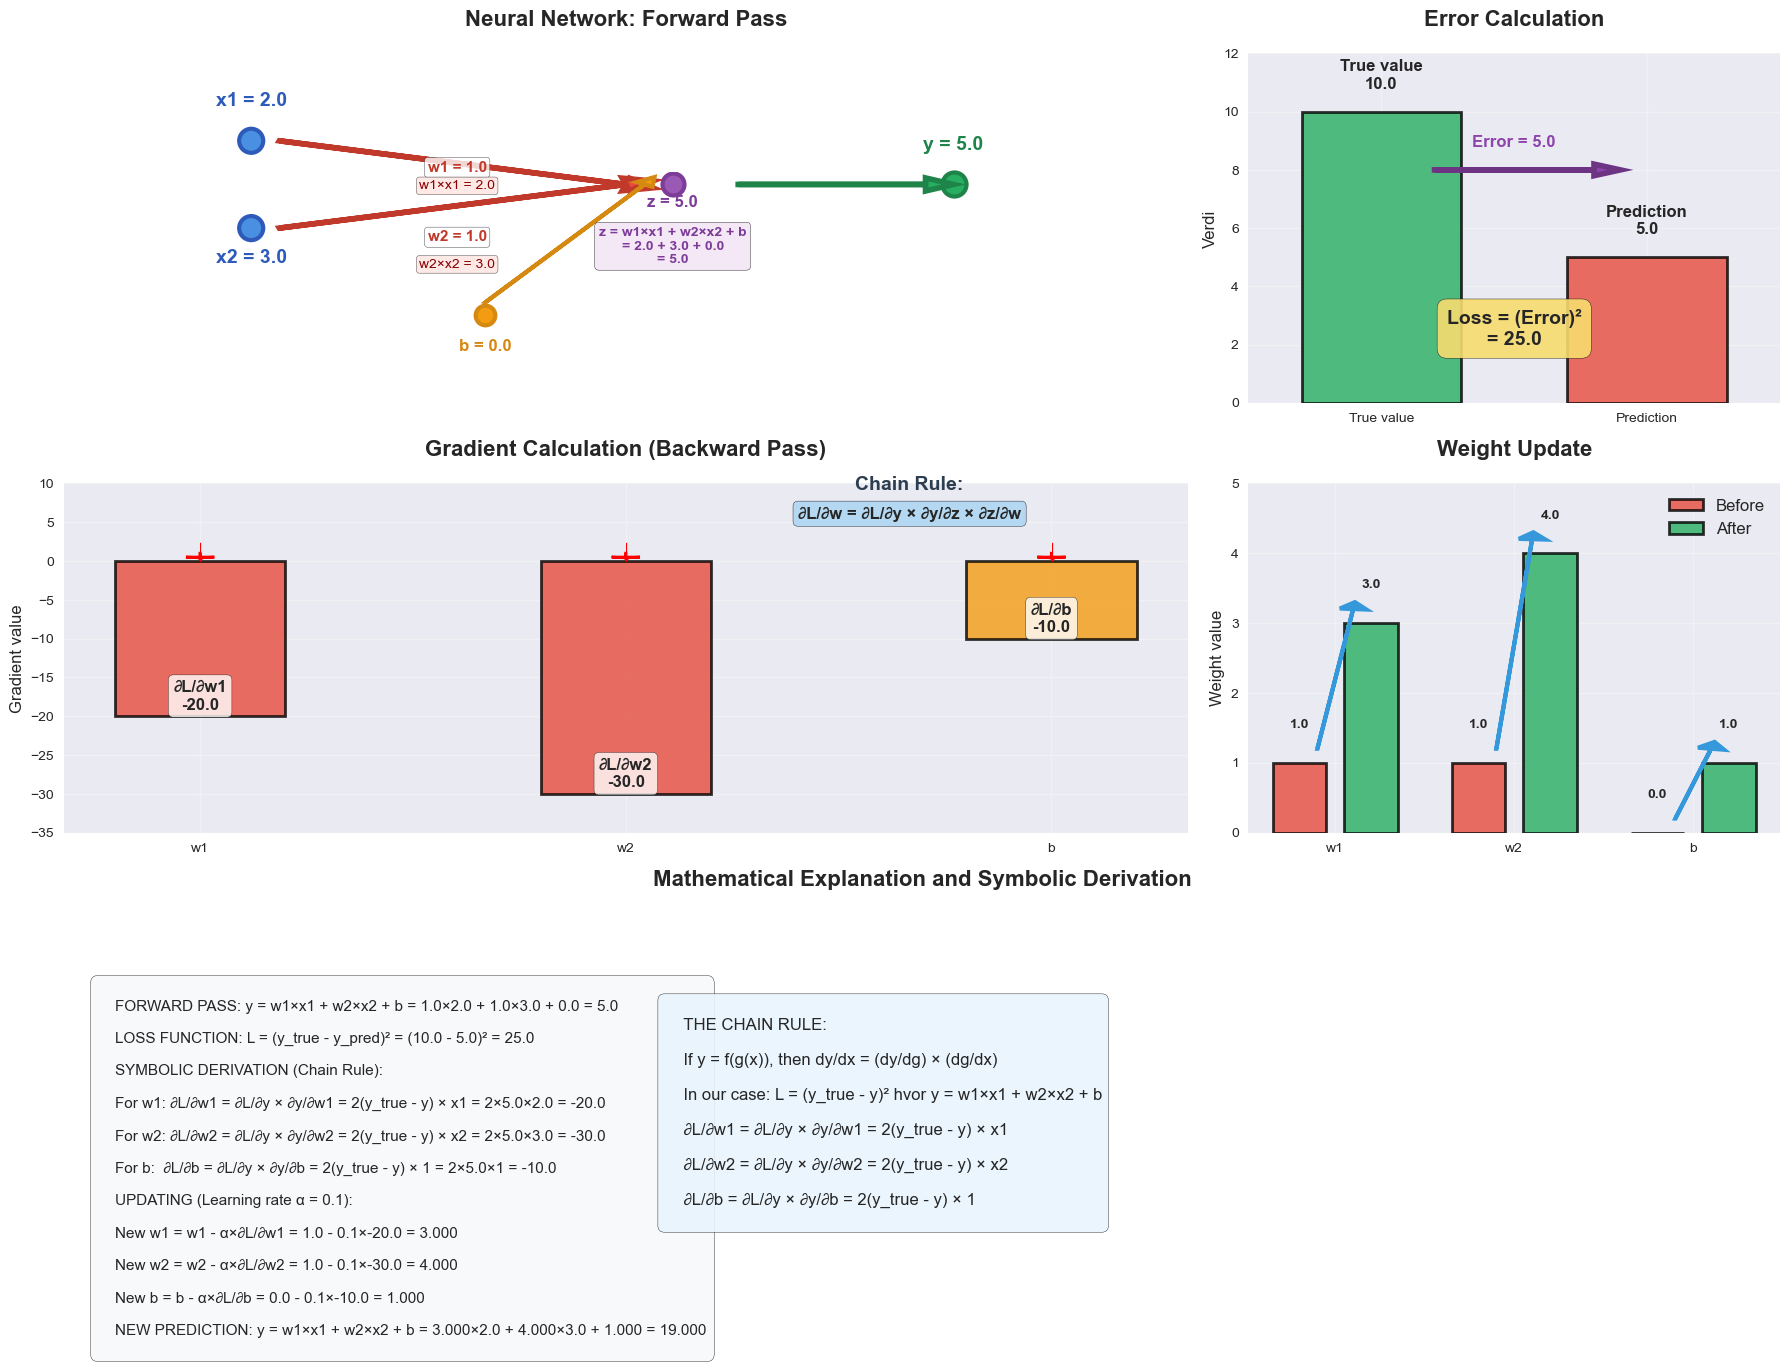

📊 === DETAILED INFORMATION ===
Input: x₁ = 2.0, x₂ = 3.0
True value: 10.0
Initial weights: w₁ = 1.0, w₂ = 1.0, b = 0.0

🔄 === FORWARD PASS ===
y = w1×x1 + w2×x2 + b = 1.0×2.0 + 1.0×3.0 + 0.0 = 5.0
Loss = (y_true - y_pred)² = (10.0 - 5.0)² = 25.0

⬅️ === BACKWARD PASS (GRADIENTS) ===
∂L/∂w1 = 2×(y_true - y_pred)×(-x1) = 2×5.0×(-2.0) = -20.0
∂L/∂w2 = 2×(y_true - y_pred)×(-x2) = 2×5.0×(-3.0) = -30.0
∂L/∂b = 2×(y_true - y_pred)×(-1) = 2×5.0×(-1) = -10.0

🔄 === WEIGHT UPDATE ===
New w1 = w1 - α×∂L/∂w1 = 1.0 - 0.1×-20.0 = 3.000
New w2 = w2 - α×∂L/∂w2 = 1.0 - 0.1×-30.0 = 4.000
New b = b - α×∂L/∂b = 0.0 - 0.1×-10.0 = 1.000

🔄 === NEW PREDICTION ===
y = w1×x1 + w2×x2 + b = 3.000×2.0 + 4.000×3.0 + 1.000 = 19.000


In [7]:
# Visual demonstration of backpropagation
def visualize_backpropagation():
    """Improved visual demonstration of backpropagation with more illustrative design"""
    
    # Define a simple function: y = w1*x1 + w2*x2 + b
    # Loss: L = (y_true - y_pred)²
    
    # Input data
    x1 = torch.tensor(2.0, requires_grad=False)
    x2 = torch.tensor(3.0, requires_grad=False)
    y_true = torch.tensor(10.0, requires_grad=False)
    
    # Model parameters (need gradients)
    w1 = torch.tensor(1.0, requires_grad=True)
    w2 = torch.tensor(1.0, requires_grad=True)
    b = torch.tensor(0.0, requires_grad=True)
    
    print("🧠 === BACKPROPAGATION DEMONSTRATION === 🧠")
    print()
    
    # Forward pass
    y_pred = w1 * x1 + w2 * x2 + b
    loss = (y_true - y_pred) ** 2
    
    # Backward pass (calculate gradients)
    loss.backward()
    
    # Create visualization with better layout
    fig = plt.figure(figsize=(18, 14))
    
    # Create grid layout
    gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1])
    
    # 1. Neural network diagram (improved with summation node)
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 10)
    ax1.set_title('Neural Network: Forward Pass', fontsize=16, fontweight='bold', pad=20)
    
    # Input layer
    ax1.scatter([2, 2], [7, 5], s=300, c=['#4A90E2', '#4A90E2'], edgecolors='#2E5BBA', linewidth=3)
    ax1.text(2, 7.8, f'x1 = {x1.item()}', ha='center', fontsize=14, fontweight='bold', color='#2E5BBA')
    ax1.text(2, 4.2, f'x2 = {x2.item()}', ha='center', fontsize=14, fontweight='bold', color='#2E5BBA')
    
    # Weights and arrows to summation node (starter i de blå nodene)
    ax1.arrow(2.3, 7, 3.7, -1, head_width=0.3, head_length=0.3, fc='#E74C3C', ec='#C0392B', linewidth=4)
    ax1.arrow(2.3, 5, 3.7, 1, head_width=0.3, head_length=0.3, fc='#E74C3C', ec='#C0392B', linewidth=4)
    ax1.text(4.2, 6.3, f'w1 = {w1.item()}', ha='center', fontsize=11, color='#C0392B', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    ax1.text(4.2, 4.7, f'w2 = {w2.item()}', ha='center', fontsize=11, color='#C0392B', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    
    # Show intermediate calculations
    ax1.text(4.2, 5.9, f'w1×x1 = {w1.item()*x1.item():.1f}', ha='center', fontsize=10, color='#8B0000', 
             bbox=dict(boxstyle="round,pad=0.2", facecolor="#FFE4E1", alpha=0.8))
    ax1.text(4.2, 4.1, f'w2×x2 = {w2.item()*x2.item():.1f}', ha='center', fontsize=10, color='#8B0000',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="#FFE4E1", alpha=0.8))
    
    # Summation node
    ax1.scatter([6.5], [6], s=250, c='#9B59B6', edgecolors='#7D3C98', linewidth=3)
    ax1.text(6.5, 6.3, 'Σ', ha='center', fontsize=16, fontweight='bold', color='white')
    ax1.text(6.5, 5.5, f'z = {y_pred.item():.1f}', ha='center', fontsize=12, fontweight='bold', color='#7D3C98')
    
    # Arrows from weights to summation node (fjernet de korte pilene)
    
    # Bias to summation node (starter i den oransje noden)
    ax1.scatter([4.5], [3], s=200, c='#F39C12', edgecolors='#D68910', linewidth=3)
    ax1.text(4.5, 2.2, f'b = {b.item()}', ha='center', fontsize=12, color='#D68910', fontweight='bold')
    ax1.arrow(4.5, 3.3, 1.7, 2.7, head_width=0.2, head_length=0.2, fc='#F39C12', ec='#D68910', linewidth=3)
    
    # Output from summation node
    ax1.scatter([9.5], [6], s=300, c='#27AE60', edgecolors='#1E8449', linewidth=3)
    ax1.text(9.5, 6.8, f'y = {y_pred.item():.1f}', ha='center', fontsize=14, fontweight='bold', color='#1E8449')
    ax1.arrow(7.2, 6, 2, 0, head_width=0.3, head_length=0.3, fc='#27AE60', ec='#1E8449', linewidth=4)
    
    # Show summation formula
    ax1.text(6.5, 4.2, f'z = w1×x1 + w2×x2 + b\n= {w1.item()*x1.item():.1f} + {w2.item()*x2.item():.1f} + {b.item():.1f}\n= {y_pred.item():.1f}', 
             ha='center', fontsize=10, color='#7D3C98', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#F3E5F5", alpha=0.9))
    
    ax1.set_xlim(0, 12)
    ax1.set_ylim(1, 9)
    ax1.axis('off')
    
    # 2. Error calculation (større)
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.set_title('Error Calculation', fontsize=16, fontweight='bold', pad=20)
    
    # True value vs prediksjon med bedre design
    bars = ax2.bar([1, 2], [y_true.item(), y_pred.item()], width=0.6, 
                   color=['#27AE60', '#E74C3C'], alpha=0.8, edgecolor='black', linewidth=2)
    ax2.text(1, y_true.item() + 0.8, f'True value\n{y_true.item()}', ha='center', fontsize=12, fontweight='bold')
    ax2.text(2, y_pred.item() + 0.8, f'Prediction\n{y_pred.item():.1f}', ha='center', fontsize=12, fontweight='bold')
    
    # Error arrow with better design
    ax2.arrow(1.2, 8, 0.6, 0, head_width=0.4, head_length=0.1, fc='#8E44AD', ec='#6C3483', linewidth=4)
    ax2.text(1.5, 8.8, f'Error = {y_true.item() - y_pred.item():.1f}', ha='center', fontsize=12, color='#8E44AD', fontweight='bold')
    
    # Loss med bedre design
    ax2.text(1.5, 2, f'Loss = (Error)²\n= {loss.item():.1f}', ha='center', fontsize=14, 
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#F7DC6F", alpha=0.9), fontweight='bold')
    
    ax2.set_ylim(0, 12)
    ax2.set_xlim(0.5, 2.5)
    ax2.set_ylabel('Verdi', fontsize=12)
    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(['True value', 'Prediction'])
    ax2.grid(True, alpha=0.3)
    
    # 3. Gradient calculation (større og mer illustrativ)
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.set_title('Gradient Calculation (Backward Pass)', fontsize=16, fontweight='bold', pad=20)
    
    # Chain rule with better design (flyttet for å unngå kollisjon)
    ax3.text(4, 9.2, 'Chain Rule:', ha='center', fontsize=14, fontweight='bold', color='#2C3E50')
    ax3.text(4, 5.5, '∂L/∂w = ∂L/∂y × ∂y/∂z × ∂z/∂w', ha='center', fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#AED6F1", alpha=0.9), fontweight='bold')
    
    # Gradients med bedre visualisering
    gradients = [w1.grad.item(), w2.grad.item(), b.grad.item()]
    labels = ['∂L/∂w1', '∂L/∂w2', '∂L/∂b']
    colors = ['#E74C3C', '#E74C3C', '#F39C12']
    
    # Create gradient bars with better design
    x_pos = [1.5, 3, 4.5]
    bars = ax3.bar(x_pos, gradients, width=0.6, color=colors, alpha=0.8, 
                   edgecolor='black', linewidth=2)
    
    # Add gradient values above bars
    for i, (bar, grad, label) in enumerate(zip(bars, gradients, labels)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{label}\n{grad:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Add arrows showing direction
    for i, grad in enumerate(gradients):
        if grad < 0:
            ax3.arrow(x_pos[i], 1, 0, -0.5, head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2)
            ax3.text(x_pos[i], 0.5, '↓', ha='center', fontsize=16, color='red', fontweight='bold')
        else:
            ax3.arrow(x_pos[i], 1, 0, 0.5, head_width=0.1, head_length=0.1, fc='green', ec='green', linewidth=2)
            ax3.text(x_pos[i], 1.5, '↑', ha='center', fontsize=16, color='green', fontweight='bold')
    
    ax3.set_ylabel('Gradient value', fontsize=12)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(['w1', 'w2', 'b'])
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(-35, 10)
    
    # 4. Weight update (større og mer illustrativ)
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.set_title('Weight Update', fontsize=16, fontweight='bold', pad=20)
    
    # Before and after with better design
    learning_rate = 0.1
    w1_new = w1.item() - learning_rate * w1.grad.item()
    w2_new = w2.item() - learning_rate * w2.grad.item()
    b_new = b.item() - learning_rate * b.grad.item()
    
    x_pos = [1, 2, 3]
    old_weights = [w1.item(), w2.item(), b.item()]
    new_weights = [w1_new, w2_new, b_new]
    labels = ['w1', 'w2', 'b']
    
    # Old weights
    bars1 = ax4.bar([x - 0.2 for x in x_pos], old_weights, width=0.3, 
                    color='#E74C3C', alpha=0.8, label='Before', edgecolor='black', linewidth=2)
    
    # New weights
    bars2 = ax4.bar([x + 0.2 for x in x_pos], new_weights, width=0.3, 
                    color='#27AE60', alpha=0.8, label='After', edgecolor='black', linewidth=2)
    
    # Arrows showing change with better design
    for i, (old, new) in enumerate(zip(old_weights, new_weights)):
        if old != new:
            arrow_color = '#3498DB' if new > old else '#E67E22'
            ax4.arrow(x_pos[i] - 0.1, old + 0.2, 0.2, new - old, 
                     head_width=0.15, head_length=0.1, fc=arrow_color, ec=arrow_color, linewidth=3)
    
    # Add values above bars
    for i, (old, new) in enumerate(zip(old_weights, new_weights)):
        ax4.text(x_pos[i] - 0.2, old + 0.5, f'{old:.1f}', ha='center', fontsize=10, fontweight='bold')
        ax4.text(x_pos[i] + 0.2, new + 0.5, f'{new:.1f}', ha='center', fontsize=10, fontweight='bold')
    
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(labels)
    ax4.set_ylabel('Weight value', fontsize=12)
    ax4.legend(fontsize=12)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 5)
    
    # 5. Mathematical explanation 
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    ax5.set_title('Mathematical Explanation and Symbolic Derivation', fontsize=16, fontweight='bold', pad=20)
    
    # Add mathematical formulas
    explanation_text = f"""
    FORWARD PASS: y = w1×x1 + w2×x2 + b = {w1.item()}×{x1.item()} + {w2.item()}×{x2.item()} + {b.item()} = {y_pred.item():.1f}
    
    LOSS FUNCTION: L = (y_true - y_pred)² = ({y_true.item()} - {y_pred.item():.1f})² = {loss.item():.1f}
    
    SYMBOLIC DERIVATION (Chain Rule):
    
    For w1: ∂L/∂w1 = ∂L/∂y × ∂y/∂w1 = 2(y_true - y) × x1 = 2×{y_true.item() - y_pred.item():.1f}×{x1.item()} = {w1.grad.item():.1f}
    
    For w2: ∂L/∂w2 = ∂L/∂y × ∂y/∂w2 = 2(y_true - y) × x2 = 2×{y_true.item() - y_pred.item():.1f}×{x2.item()} = {w2.grad.item():.1f}
    
    For b:  ∂L/∂b = ∂L/∂y × ∂y/∂b = 2(y_true - y) × 1 = 2×{y_true.item() - y_pred.item():.1f}×1 = {b.grad.item():.1f}
    
    UPDATING (Learning rate α = 0.1):
    
    New w1 = w1 - α×∂L/∂w1 = {w1.item()} - 0.1×{w1.grad.item():.1f} = {w1_new:.3f}

    New w2 = w2 - α×∂L/∂w2 = {w2.item()} - 0.1×{w2.grad.item():.1f} = {w2_new:.3f}
    
    New b = b - α×∂L/∂b = {b.item()} - 0.1×{b.grad.item():.1f} = {b_new:.3f}
    
    NEW PREDICTION: y = w1×x1 + w2×x2 + b = {w1_new:.3f}×{x1.item()} + {w2_new:.3f}×{x2.item()} + {b_new:.3f} = {w1_new*x1.item() + w2_new*x2.item() + b_new:.3f}
    """
    
    ax5.text(0.02, 0.8, explanation_text, ha='left', va='top', fontsize=11, 
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#F8F9FA", alpha=0.9))
    
    # Add chain rule as separate section (lower right)
    chain_rule_text = """
    THE CHAIN RULE:
    
    If y = f(g(x)), then dy/dx = (dy/dg) × (dg/dx)
    
    In our case: L = (y_true - y)² hvor y = w1×x1 + w2×x2 + b
    
    ∂L/∂w1 = ∂L/∂y × ∂y/∂w1 = 2(y_true - y) × x1

    ∂L/∂w2 = ∂L/∂y × ∂y/∂w2 = 2(y_true - y) × x2  
    
    ∂L/∂b = ∂L/∂y × ∂y/∂b = 2(y_true - y) × 1
    """
    
    ax5.text(0.35, 0.75, chain_rule_text, ha='left', va='top', fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#E8F4FD", alpha=0.9))
    
    plt.tight_layout()

    # Write the figure to a png file kalt illustrasjon-av-backpropagation.png
    plt.savefig('./resources/backpropagation-illustration.png', dpi=300)

    plt.show()
    
    # Print detaljert informasjon
    print("📊 === DETAILED INFORMATION ===")
    print(f"Input: x₁ = {x1.item()}, x₂ = {x2.item()}")
    print(f"True value: {y_true.item()}")
    print(f"Initial weights: w₁ = {w1.item()}, w₂ = {w2.item()}, b = {b.item()}")
    print()
    print("🔄 === FORWARD PASS ===")
    print(f"y = w1×x1 + w2×x2 + b = {w1.item()}×{x1.item()} + {w2.item()}×{x2.item()} + {b.item()} = {y_pred.item()}")
    print(f"Loss = (y_true - y_pred)² = ({y_true.item()} - {y_pred.item()})² = {loss.item()}")
    print()
    print("⬅️ === BACKWARD PASS (GRADIENTS) ===")
    print(f"∂L/∂w1 = 2×(y_true - y_pred)×(-x1) = 2×{y_true.item() - y_pred.item()}×(-{x1.item()}) = {w1.grad.item()}")
    print(f"∂L/∂w2 = 2×(y_true - y_pred)×(-x2) = 2×{y_true.item() - y_pred.item()}×(-{x2.item()}) = {w2.grad.item()}")
    print(f"∂L/∂b = 2×(y_true - y_pred)×(-1) = 2×{y_true.item() - y_pred.item()}×(-1) = {b.grad.item()}")
    print()
    print("🔄 === WEIGHT UPDATE ===")
    print(f"New w1 = w1 - α×∂L/∂w1 = {w1.item()} - 0.1×{w1.grad.item()} = {w1_new:.3f}")
    print(f"New w2 = w2 - α×∂L/∂w2 = {w2.item()} - 0.1×{w2.grad.item()} = {w2_new:.3f}")
    print(f"New b = b - α×∂L/∂b = {b.item()} - 0.1×{b.grad.item()} = {b_new:.3f}")
    print()
    print("🔄 === NEW PREDICTION ===")
    print(f"y = w1×x1 + w2×x2 + b = {w1_new:.3f}×{x1.item()} + {w2_new:.3f}×{x2.item()} + {b_new:.3f} = {w1_new*x1.item() + w2_new*x2.item() + b_new:.3f}")

# Run the improved visual demonstration
visualize_backpropagation()


### ✅ Check Your Understanding: Backpropagation

**Q1:** What is the chain rule, and why is it essential for backpropagation?

<details>
<summary>Click for answer</summary>

**Answer:** The chain rule is a calculus rule for computing derivatives of composite functions:

**If** z = f(y) and y = g(x), **then** dz/dx = dz/dy × dy/dx

**Why essential for backprop:**
- Neural networks are composed of many nested functions (layer after layer)
- To compute ∂Loss/∂weight, we need to "chain" through all intermediate layers
- Without the chain rule, we couldn't efficiently compute gradients in deep networks

**Example:** For Loss → FC2 → ReLU → FC1 → Input:
```
∂Loss/∂FC1_weight = (∂Loss/∂FC2_out) × (∂FC2_out/∂ReLU_out) × (∂ReLU_out/∂FC1_out) × (∂FC1_out/∂FC1_weight)
```
</details>

**Q2:** Why is backpropagation more efficient than computing each gradient separately?

<details>
<summary>Click for answer</summary>

**Answer:** Backpropagation reuses intermediate computations:

| Approach | Complexity | Example (n layers, m params) |
|----------|------------|------------------------------|
| Separate computation | O(n × m) | Compute full chain for EACH weight |
| Backpropagation | O(n + m) | Compute chain ONCE, reuse results |

**Key insight:** ∂Loss/∂Layer_k is computed once and used for ALL weights in that layer.

This efficiency makes training deep networks with millions of parameters feasible!
</details>

**Q3:** What does `requires_grad=True` do in PyTorch?

<details>
<summary>Click for answer</summary>

**Answer:** `requires_grad=True` tells PyTorch to:
1. **Track all operations** on this tensor
2. **Build a computation graph** automatically
3. **Compute gradients** when `.backward()` is called

```python
w = torch.tensor(1.0, requires_grad=True)   # ← Track this!
x = torch.tensor(2.0, requires_grad=False)  # ← Don't track (just data)
y = w * x                                    # PyTorch records: y = w × x
y.backward()                                 # Compute ∂y/∂w = x = 2.0
print(w.grad)                                # → tensor(2.)
```

PyTorch handles all the calculus for you!
</details>

> 🏥 **Medical AI Insight:** Backpropagation enables training models that can analyze complex medical images (CT, MRI, histopathology) by learning millions of parameters from labeled examples.

---

## 🤔 Why Did the Error Increase After the Update?

You noticed something important: **The error increased from 5.0 to 9.0** after the update! This happens for several reasons:

### 📈 **What Happened:**
- **Before update**: Prediction = 5.0, Error = |10.0 - 5.0| = 5.0
- **After update**: Prediction = 19.0, Error = |10.0 - 19.0| = 9.0

### 🔍 **Why This Happens:**

#### 1. **Too High Learning Rate (α = 0.1)**
- The learning rate is **too large** for this problem
- The network takes **steps that are too large** and "jumps over" the optimal point
- Like walking past the valley when going down a mountain

#### 2. **Gradients are Negative**
- All gradients are negative: w1=-20, w2=-30, b=-10
- This means the weights must be **increased** to reduce the error
- But we increased them **too much** in one step

#### 3. **Non-Linear Problem**
- Even though the function looks linear, the optimization is complex
- Large changes can lead to **oscillation** around the optimum

### 🛠️ **How to Fix This:**

#### **Reduce the Learning Rate:**
- Try α = 0.01 instead of 0.1
- Smaller steps = more stable learning

#### **Iterative Update:**
- Repeat the process multiple times with smaller steps
- Each iteration will bring us closer to the optimum

#### **Adaptive Learning Rates:**
- Modern algorithms adjust the learning rate automatically
- E.g., Adam, RMSprop, AdaGrad

### 🎯 **Takeaway:**
This demonstrates that **learning in AI is not always linear** - sometimes we have to "go back" to find the best solution.

**In the next iteration** the network would adjust in the opposite direction and gradually find the optimal point.


_The difference between gradient descent and backpropagation_

### What is the difference between Gradient Descent (discussed earlier) and Backpropagation

#### 🎯 **Gradient Descent: "Where should we go?"**

**Gradient descent** is the **optimization algorithm** - it determines **which direction** we should go to find the best result.

**What it does:**
- Calculates the **direction** with the greatest slope (the gradient)
- Goes in the **opposite direction** to find the minimum
- Updates **all parameters** simultaneously
- **Formula**: θ ← θ - α∇L(θ)

**Geographic analogy:**
Like being on a mountain and finding the valley by following the terrain downhill. You don't know exactly where the valley is, but you follow the direction that goes down.

#### ⚡ **Backpropagation: "How do we calculate the direction?"**

**Backpropagation** is the **calculation method** - it figures out **how** each weight affects the total error.

**What it does:**
- Calculates **gradients** for each weight in the network
- Uses the **chain rule** from calculus
- "Goes backward" through the network
- **Formel**: ∂L/∂w = ∂L/∂y × ∂y/∂z × ∂z/∂w

**Medical analogy:**
Like analyzing which factors led to an incorrect diagnosis. You systematically go through each part of the diagnostics to find out what needs to be changed.

#### 🔄 **The Connection: Two Sides of the Same Coin**

**Backpropagation** → **Gradient Descent**
1. **Backpropagation** calculates the gradients (how much each weight affects the error)
2. **Gradient descent** uses these gradients to update the weights

**Practical example:**
- **Backpropagation**: "Weight w1 affects the error by -20, w2 by -30"
- **Gradient descent**: "Let's increase w1 by 2.0 and w2 by 3.0 to reduce the error"

#### 📊 **Visual Comparison**

| Aspect | Gradient Descent | Backpropagation |
|--------|---------------------|-----------------|
| **Main Task** | Optimization | Calculation of gradients |
| **Question** | "Where should we go?" | "How do we calculate the direction?" |
| **Input** | Gradients | Network architecture + error |
| **Output** | Updated weights | Gradients for each weight |
| **Time Scale** | Each iteration | Each iteration |
| **Mathematics** | Simple subtraction | Complex differentiation |

#### 🧠 **In Practice: How They Work Together**

**Step 1: Forward Pass**
- The network makes a prediction
- We calculate the error

**Step 2: Backpropagation**
- Calculates how each weight affects the error
- Gives us the gradients

**Step 3: Gradient Descent**
- Uses the gradients to update the weights
- Goes in the direction that reduces the error

**Step 4: Repeat**
- Continue until the network has learned

#### 🎯 **Why This is Important for Healthcare Professionals**

**Understanding AI limitations:**
- AI does not "learn" like humans
- They are mathematical algorithms that optimize parameters
- **Backpropagation** is not biologically plausible

**Clinical relevance:**
- Helps understand why AI can make mistakes
- Important for assessing the reliability of AI systems
- Significant for implementing AI in clinical practice

#### 📚 **Summary**

**Gradient descent** and **backpropagation** are two parts of the same learning process:

- **Backpropagation** = "How do we calculate the direction?"
- **Gradient descent** = "Where should we go?"

Without backpropagation, we wouldn't know which direction to go. Without gradient descent, we couldn't update the weights. Together, they allow neural networks to learn from data and improve their predictions.

_I have heard about batch updates, how does this come into play?_

Batch update is an important technique in machine learning that affects both gradient descent and backpropagation. 

### 🍽️ **Batch Update: What is it?**

**Batch** = a group of examples (data points, instances, subsets of training data) that are processed simultaneously<br>
**Batch update** = updates the weights based on multiple examples at a time, not just one

#### 📊 **Three Types of Updates**

##### 1. **Stochastic Gradient Descent (SGD)**
- **Batch size**: 1
- **How**: Updates weights after each example
- **Advantage**: Fast update, can learn from new data quickly
- **Disadvantage**: Unstable, can "jump around" in parameter space

##### 2. **Batch Gradient Descent**
- **Batch size**: Entire dataset
- **How**: Updates weights after seeing all examples
- **Advantage**: Stable, converges to global minimum
- **Disadvantage**: Slow, requires a lot of memory

##### 3. **Mini-batch Gradient Descent** ⭐
- **Batch size**: 32-256 examples (typical)
- **How**: Updates weights after each mini-batch
- **Advantage**: Balances stability and speed
- **Disadvantage**: Requires tuning of batch size

#### 🔄 **How Batch Update Works**

##### **Forward Pass for a Batch:**
```python
# For each example in the batch
for i in range(batch_size):
    prediction[i] = model(input[i])
    loss[i] = criterion(prediction[i], target[i])

# Average loss for the batch
batch_loss = torch.mean(loss)
```

##### **Backpropagation for a Batch:**
```python
# Calculate gradienter for hele batchen
batch_loss.backward()

# The gradients are now the average over all examples in the batch
# ∂L/∂w = (1/batch_size) * Σ(∂L_i/∂w)
```

##### **Gradient Descent with Batch:**
```python
# Update weights based on average gradients
optimizer.step()
```

#### 📈 **Visual Comparison**

The difference can be illustrated with a practical example:

```python
# Example: Medical diagnosis with different batch sizes

# SGD (batch_size = 1)
for patient in patients:
    prediction = model(patient.features)
    loss = criterion(prediction, patient.diagnosis)
    loss.backward()  # Oppdaterer vekter
    optimizer.step()

# Mini-batch (batch_size = 32)
for batch in batches_of_32_patients:
    predictions = model(batch.features)
    losses = criterion(predictions, batch.diagnoses)
    batch_loss = torch.mean(losses)
    batch_loss.backward()  # Oppdaterer vekter
    optimizer.step()

# Batch (batch_size = all_patients)
all_predictions = model(all_patients.features)
all_losses = criterion(all_predictions, all_patients.diagnoses)
total_loss = torch.mean(all_losses)
total_loss.backward()  # Oppdaterer vekter
optimizer.step()
```

#### 🎯 **Why Batch Update is Important**

##### **1. Stability**
- **Larger batch** = more stable learning
- **Smaller batch** = more variation, but can avoid local minima

##### **2. Speed**
- **Larger batch** = fewer updates, but slower per update
- **Smaller batch** = more updates, but faster per update

##### **3. Memory Usage**
- **Larger batch** = requires more memory
- **Smaller batch** = requires less memory

##### **4. Generalization** (*)
- **Larger batch** = can generalize better
- **Smaller batch** = can avoid overfitting

(*) This looks contradictory at first glance, but:


### 🤔 **Apparent Contradiction: Generalization vs Overfitting**

#### 📊 **The Complex Relationship between Batch Size and Generalization**

##### **1. Larger Batch = Better Generalization (generally)**
**Why:**
- **More stable learning**: Fewer "jumps" in parameter space
- **Better gradient estimates**: Average over more examples
- **Less noise**: Individual examples affect less
- **More consistent**: Learns from representative sample

**Medical example:**
- With batch size 128, the model learns from 128 patients simultaneously
- A single patient with unusual symptoms affects learning less
- The model gets a more balanced picture of the disease

##### **2. Smaller Batch = Can Avoid Overfitting (in specific cases)**
**Why:**
- **More noise**: Can "jump out" of local minima
- **Better exploration**: Explores parameter space more
- **Less risk of "getting stuck"**: Does not overfit to specific patterns

**Medical example:**
- With batch size 1, the model can learn from each individual patient
- Can detect rare but important patterns
- Avoids overfitting to common cases

#### 🎯 **The Important Distinction**

##### **Generalization ≠ Overfitting Prevention**

**Generalization** = How well the model works on new data
**Overfitting prevention** = How well the model avoids overfitting

#### 📈 **The U-Shaped Curve**

```python
# Conceptual illustration of the relationship
batch_sizes = [1, 8, 32, 64, 128, 256, 512, 1024]
generalization_scores = [0.6, 0.7, 0.85, 0.9, 0.88, 0.85, 0.82, 0.8]
overfitting_risk = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9]

# Optimal batch size is where generalization is highest
# and overfitting risk is lowest
```

#### 🔍 **When Does Each Rule Apply?**

##### **Larger Batch for Better Generalization:**
- **Large, diverse datasets**
- **Stable, well-defined problems**
- **When you have enough data**
- **Production models**

##### **Smaller Batch for Overfitting Prevention:**
- **Small datasets**
- **Complex, noisy problems**
- **When you have little data**
- **Research models**

#### 🏥 **Medical Example: Cardiovascular Disease**

##### **Scenario 1: Large, representative database**
```python
# 100,000 patients, well-balanced
# Recommendation: Larger batch (128-256)
# Reason: Better generalization, less noise
```

##### **Scenario 2: Small, rare diseases**
```python
# 1,000 patients, rare cases
# Recommendation: Smaller batch (16-32)
# Reason: Avoid overfitting, explore rare patterns
```

#### 📊 **Practical Advice**

##### **Start with Medium Batch:**
```python
# Start with batch size 32-64
# Monitor both generalization and overfitting
# Adjust based on results
```

##### **Indicators for Optimal Batch Size:**
- **High test accuracy** (good generalization)
- **Small gap between training/test accuracy** (low overfitting)
- **Stable loss curve** (good convergence)

#### 🎯 **Updated Table**

| Batch Size | Generalization | Overfitting Risk | Recommendation |
|----------------|----------------|-------------------|------------|
| **1-8** | Low | Low | Small datasets, rare diseases |
| **32-64** | High | Medium | **Start here** |
| **128-256** | High | Medium | Large datasets, production |
| **512+** | Medium | High | Very large datasets |

#### 📚 **Conclusion**

The solution to this apparent contradiction is: 

1. **Both statements are true** - but in different contexts
2. **Generalization and overfitting prevention** are related but different concepts
3. **Optimal batch size** balances both factors
4. **Context is important** - dataset size, problem complexity, etc.

**Practical advice:** Start with batch size 32-64, and adjust based on how the model performs on both training and test data. <br>
Often the size of **available GPU memory** (e.g., VRAM: 8 GB, 16 GB, 32 GB) also sets a constraint on batch size (e.g., batch sizes 2, 4, 8)




#### 🏥 **Medical Example: Cardiovascular Disease Prediction**

```python
# Practical example with PyTorch
class MedicalDiagnosisNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Different batch sizes
batch_sizes = [1, 32, 128, 512]

for batch_size in batch_sizes:
    print(f"\n=== Batch size: {batch_size} ===")
    
    # Create DataLoader with desired batch size
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(10):
        for batch_features, batch_targets in dataloader:
            # Forward pass
            predictions = model(batch_features)
            loss = criterion(predictions, batch_targets)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")
```

#### 📊 **Comparison of Batch Sizes**

| Batch Size | Stability | Speed | Memory | Generalization |
|----------------|------------|-----------|-------|----------------|
| **1 (SGD)** | Low | High | Low | Varying |
| **32-64** | Medium | High | Medium | Good |
| **128-256** | High | Medium | High | Good |
| **Entire dataset** | Highest | Low | Highest | Best |

#### 🎯 **Practical Recommendations for Medical AI**

##### **Start with Mini-batch:**
- **Batch size**: 32-64
- **Reason**: Balances stability and speed
- **Adjust**: Increase if you have lots of memory, decrease if you have little

##### **Adjust to dataset:**
- **Large datasets**: Use larger batch
- **Small datasets**: Use smaller batch
- **Imbalanced datasets**: Consider weighted sampling

##### **Monitor training:**
- **Stable loss**: Batch size is working
- **Oscillating loss**: Try larger batch
- **Slow training**: Try smaller batch

#### 🔍 **Advanced Techniques**

##### **1. Gradient Accumulation**
```python
# Simulates larger batch when you have little memory
accumulation_steps = 4
for i, (features, targets) in enumerate(dataloader):
    predictions = model(features)
    loss = criterion(predictions, targets) / accumulation_steps
    loss.backward()
    
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()
```

##### **2. Adaptive Batch Size**
```python
# Increase batch size when loss stabilizes
if loss_has_stabilized:
    batch_size *= 2
    dataloader = DataLoader(dataset, batch_size=batch_size)
```

#### 📚 **Summary**

**Batch update** affects both gradient descent and backpropagation:

- **Backpropagation**: Calculates gradients for the entire batch simultaneously
- **Gradient descent**: Updates weights based on average gradients

**Main benefits:**
- **Stability**: More stable learning
- **Efficiency**: Better utilization of modern hardware
- **Generalization**: Better generalization to new data

**For medical AI:**
- Start with batch size 32-64
- Adjust based on dataset and hardware (GPU VRAM)
- Monitor training to find optimal size

This is one of the most important hyperparameters to tune when training neural networks for medical applications.

-----

---

## 📚 Glossary of Key Terms

### Biological Learning

| Term | Definition |
|------|------------|
| **BDNF** | Brain-Derived Neurotrophic Factor - promotes neuronal growth and plasticity |
| **Hebb's Rule** | "Neurons that fire together, wire together" - simultaneous activation strengthens connections |
| **LTD** | Long-Term Depression - weakening of synaptic connections |
| **LTP** | Long-Term Potentiation - strengthening of synaptic connections |
| **Neuroplasticity** | Brain's ability to reorganize and form new connections |
| **NMDA Receptor** | Ion channel involved in synaptic plasticity and learning |

### Optimization & Learning

| Term | Definition |
|------|------------|
| **Backpropagation** | Algorithm to compute gradients by applying chain rule backward through network |
| **Batch size** | Number of samples processed before updating weights |
| **Chain rule** | Calculus rule: d(f∘g)/dx = df/dg × dg/dx |
| **Convergence** | When optimization reaches (near) minimum loss |
| **Epoch** | One complete pass through the entire training dataset |
| **Gradient** | Vector of partial derivatives pointing toward steepest ascent |
| **Gradient descent** | Optimization by iteratively moving in negative gradient direction |
| **Learning rate (α)** | Step size for weight updates (hyperparameter) |
| **Local minimum** | Point where loss is minimum locally but not globally |
| **Loss function** | Measures how wrong predictions are (we minimize this) |
| **Mini-batch** | Subset of training data used per weight update |
| **SGD** | Stochastic Gradient Descent - update after each sample |

### PyTorch Specifics

| Term | Definition |
|------|------------|
| **Autograd** | PyTorch's automatic differentiation engine |
| **Computation graph** | Record of operations for automatic gradient computation |
| **requires_grad** | Flag to enable gradient tracking for a tensor |
| **.backward()** | Method to compute gradients via backpropagation |
| **.grad** | Attribute storing computed gradient for a tensor |

## Summary and The Way Forward

### What We Have Learned

1. **Gradient Descent** is the core of learning - we find the minimum by following the gradient
2. **Backpropagation** calculates gradients automatically using the chain rule
3. **Training** involves iteratively updating weights to minimize error
4. **Overfitting** is a major challenge that can be solved with regularization*
5. **Generalization** is the goal - the model should work on new data

(*) **Regularization** refers to techniques that add "penalties" for complex models, so they don't learn too specifically on training data and can generalize better to new, unseen data.

### Practical Tips for Medical AI

- **Start simple**: Begin with simple models first
- **Validate thoroughly**: Use cross-validation and holdout sets
- **Be skeptical**: Test the model on new data before implementation
- **Document everything**: Keep track of hyperparameters and results
- **Collaborate**: Include clinicians in the development process

### Next Step: Classification of UCI Heart Disease dataset with deep learning model

In the next part (`B3-heart-disease-classification.ipynb`) we will explore:
1. **Download and preprocessing** of real UCI Heart Disease data
2. **Exploratory data analysis** with visualizations
3. **Improved neural network** with batch normalization and dropout
4. **Detailed training** with adaptive learning rate
5. **Comprehensive evaluation** with confusion matrix, ROC curve and performance metrics
6. **Feature importance analysis** to understand which factors are most important
7. **Clinical interpretation** and practical recommendations

### Reflection Questions

1. Why is overfitting especially dangerous in medical AI?
2. How can we ensure that a medical AI model generalizes well?
3. What ethical challenges do you see with automatic medical diagnostics?
4. How can we combine human expertise with machine learning?


---

## 📖 Further Reading & Resources

### Foundational Papers & Books

| Resource | Description |
|----------|-------------|
| **Rumelhart et al. (1986)** | "Learning representations by back-propagating errors" - THE backprop paper |
| **"Deep Learning" (Goodfellow et al.)** | Chapter 6-8 cover optimization and backpropagation in depth |
| **3Blue1Brown: Backpropagation** | Visual explanation of how gradients flow |
| **Andrej Karpathy: micrograd** | Build backprop from scratch in ~100 lines |

### Biology-to-AI Connections

| Biological Concept | AI Equivalent | Key Insight |
|--------------------|---------------|-------------|
| LTP/LTD | Weight updates | Strengthening/weakening connections |
| Hebb's rule | Gradient descent | Co-activation drives learning |
| BDNF | Learning rate | Controls speed of change |
| Synaptic pruning | Dropout/L1 | Removing unnecessary connections |

### Optimization Deep Dives

| Topic | What You'll Learn |
|-------|-------------------|
| **Adam optimizer** | Adaptive learning rates per parameter |
| **Learning rate schedules** | Decrease LR over time for fine-tuning |
| **Batch normalization** | Stabilize training by normalizing layers |
| **Gradient clipping** | Prevent exploding gradients in deep networks |

### Key Takeaways

```
┌──────────────────────────────────────────────────────────────────────────┐
│                    LEARNING IN NEURAL NETWORKS                           │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  FORWARD PASS              LOSS              BACKWARD PASS               │
│  ─────────────             ────              ────────────                │
│  Input → Layer1 → Layer2 → Output → Compare → ∂L/∂Out → ∂L/∂L2 → ∂L/∂L1  │
│                              ↓        with                               │
│                            Target     label                              │
│                                                                          │
│  GRADIENT DESCENT FORMULA:                                               │
│  ────────────────────────                                                │
│  θ_new = θ_old - α × ∂L/∂θ                                               │
│                                                                          │
│  Where:  θ = weight,  α = learning rate,  L = loss                       │
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘
```

**You now understand:**
- ✅ How biological neurons learn through LTP/LTD and Hebb's rule
- ✅ How gradient descent finds minimum loss by following gradients
- ✅ How backpropagation efficiently computes gradients using the chain rule
- ✅ The role of learning rate and batch size in training
- ✅ How PyTorch automates gradient computation with autograd

---

*Next: Apply these concepts to train real neural networks on MNIST!*